Aufgabe 1

python -m pip install numpy matplotlib scipy pandas scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle


#
# Neue imports für pandas und scikit-learn
#
import pandas as pd
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs

In [3]:
# Einbinden der Bibliothek für Zugriff auf die Dateistruktur
import os
# Ermitteln des current working directory und sofortige Ausgabe
print(os.getcwd())

cwd = os.getcwd()
# Erzeugen einer Liste 'files' mit allen Dateien und Ordnern im cwd
files = os.listdir(cwd)
# Ausgabe der Liste
print(files)

file = os.path.join(cwd, 'Musterloesung_Data.txt') #der Ganze Pfad oder vom Ordner ausgegehend in dem man ist
print(file)

import numpy as np

data = np.loadtxt(file, skiprows=1, delimiter=',', dtype=float, usecols=(0,1,2), commnet='#', max_rows=10, unpack=True, ndmin=2) 
#usecols ladet nur bestimmte zeilen
#Comments ignoriert alles was mit dem anfangt
#unpack transponiert es in eine Art
#ndmin gibt an wie viele Dimensionen es mindestens hat
#
print(data)

x = np.array([1, 2, 3, 4, 5])
y = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
z = np.array([-5, -6, -7, -8, -9])

np.savetxt('DataOut.txt', (x,y,z), delimiter=',', hearder='x,y,z', comments='#', fmt="%.2f", footer='Ende')
#fmt gibt an wie viele Nachkommastellen es gibt
#fmt="%.2f" ist die wissenschaftliche schreibeweise
#footer gibt an was am Ende steht

print('{:.2f}'.format(1.3502)) #Fliesskomma mit 2 Nachkommastellen d ist für interger
print('{:.4e}'.format(1.3502)) ist die wissenschaftliche schreibweise

file = os.path.join(cwd, 'Musterloesung_Data_bearbeitet.txt')
with open(file, 'r') as f:
    lines = f.readlines()
# 'r' für read, 'w' fuer write, 'a' fuer append


a = np.fromstring(lines[1], dtype=float, sep=',')
# von str zu whatever

d = np.zeros((len(lines), 3))


SyntaxError: invalid syntax (3489152246.py, line 35)

In [4]:
import numpy as np
import matplotlib.pyplot as plt



In [5]:
# python -m pip install numpy matplotlib

%pip install numpy  matplotlib




Note: you may need to restart the kernel to use updated packages.


In [6]:
%matplotlib notebook
%matplotlib inline

#interaktive Plots

Ex02 PLots

NameError: name 'data_res1' is not defined

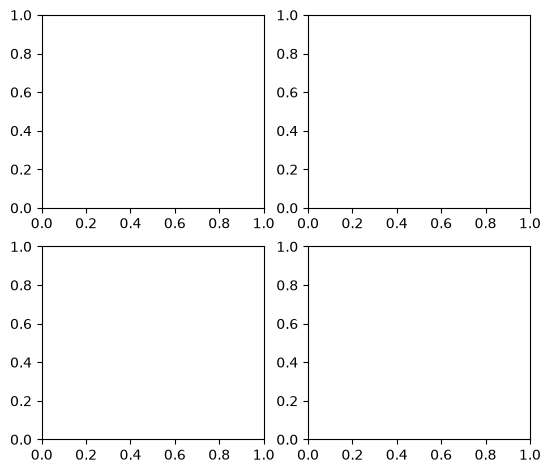

In [7]:
cm = 1 / 2.54  # Zoll zu Centimeter
fig = plt.figure(figsize=(16*cm, 14*cm)) #constrained_layout=True kann mna auch verwenden das

ax1 = fig.add_subplot(2, 2, 1) #die drei zahlen hinten sind zeilen, spalten, Die position
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

# Die Zeitachse ist jeweils in der ersten Spalte, die gemessene Spannung in der zweiten Spalte.
ax1.plot(data_res1[:, 0], data_res1[:, 1])
ax2.plot(data_res2[:, 0], data_res2[:, 1])
ax3.plot(data_res3[:, 0], data_res3[:, 1])
ax4.plot(data_res4[:, 0], data_res4[:, 1])

# Da alle Plots gleich sind, können wir die Achsenbeschriftungen etc. auch in einer Schleife generieren!
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlabel('Zeit (s)')
    ax.set_ylabel('Spannung (mV)')
    
fig.tight_layout()

In [8]:
# Probieren wir es erst mal mit einem Datensatz
measured_values = data_res1[:, 1]

# Array sortieren
sorted_values = np.sort(measured_values)

# Berechne die Differenzen zwischen aufeinanderfolgenden Werten.
differences = np.diff(sorted_values)

# Absolute Differenzen sortieren, da wir die kleinste Differenz zwischen verschiedenen Messwerten suchen
sorted_differences = np.sort(np.abs(differences))
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(sorted_differences)
ax.set_xlabel('Index')
ax.set_ylabel('Differenz (mV)')

NameError: name 'data_res1' is not defined

In [9]:
# Wir wählen eine fixe Bingrösse für alle vier Histogramme.
# Verändern Sie diesen Wert, um sich zu veranschaulichen, was mit den Histogrammen passiert.
binsize = 0.1

# Histogramme erzeugen
bin_edges = np.arange(541, 544.4, binsize) #macht einen array mit regelmässig verteilten Werten
#man kann np.min/max(data) um die spanne herauszufinden
bin_centers = bin_edges[:-1] + 0.5 * binsize
hist1, _ = np.histogram(data_res1[:, 1], bins=bin_edges)
hist2, _ = np.histogram(data_res2[:, 1], bins=bin_edges)
hist3, _ = np.histogram(data_res3[:, 1], bins=bin_edges)
hist4, _ = np.histogram(data_res4[:, 1], bins=bin_edges)

# Plots
cm = 1 / 2.54  # Zoll zu Centimeter
fig = plt.figure(figsize=(16*cm, 14*cm))

ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

ax1.bar(bin_centers, hist1, width=binsize*0.8)
ax2.bar(bin_centers, hist2, width=binsize*0.8)
ax3.bar(bin_centers, hist3, width=binsize*0.8)
ax4.bar(bin_centers, hist4, width=binsize*0.8)

ax1.set_title('dV = {:.2f} mV'.format(res1), size=10)
ax2.set_title('dV = {:.2f} mV'.format(res2), size=10)
ax3.set_title('dV = {:.2f} mV'.format(res3), size=10)
ax4.set_title('dV = {:.2f} mV'.format(res4), size=10)

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlabel('Spannung (mV)')
    ax.set_ylabel('Anz. Ereignisse')

fig.tight_layout()

NameError: name 'data_res1' is not defined

NameError: name 'time1' is not defined

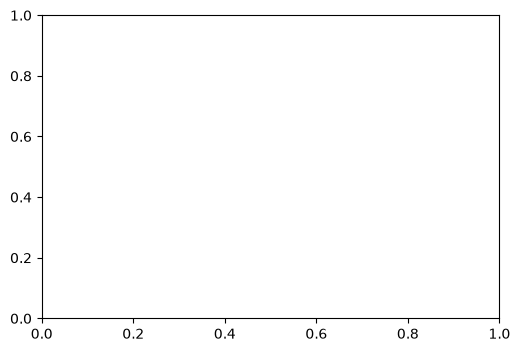

In [10]:
# Daten Potten
cm = 1 / 2.54  # Zoll zu Centimeter
fig = plt.figure(figsize=(15*cm, 10*cm))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time1, signal1, 'x-')
ax.set_xlabel('Zeit (s)')
ax.set_ylabel('Spannung (V)')
ax.set_title('sample rate: {:.1f} kHz'.format(sample_rate * 1e-3), size=10)

# Wir schauen auf einen kleineren Zeitbereich, um die Oszillation besser zu sehen.
ax.set_xlim(0, 0.1)

Ex03



Simple function

In [11]:
def hallo(input):
    print("hallo")

hallo(1)

hallo


In [12]:
liste = [i for i in range(0,1000,2)]
print(np.mean(liste))
print(np.std(liste))


499.0
288.6745572439663


Die Definition von Mittelwert und Standardabweichung ist:

$\mu = \frac{1}{N}\Sigma x_i$

$\sigma = \sqrt{\frac{1}{N}\Sigma(x_i-\mu)^2}$


In [13]:
cm = 0.393701  # Umrechnung Zoll zu Centimeter

# Wir wählen eine Binsize und erstellen dann zuerst die Bins für jede Beschleunigungskomponente.
# Wir suchen dazu das Minimum und das Maximum der vorhandenen Werte
# Anschliessend berechnen wir das Histogramm. 
binsize = 0.01
bin_edges = np.arange(np.min(V), np.max(V), binsize)
# Da die Funktion zwei Werte zurückgibt, wir aber nur am ersten interessiert sind, können
# wir folgende Syntax verwenden, um den zweiten Wert gleich zu verwerfen:
hist, _ = np.histogram(V, bin_edges)
# Das Array 'bin_edges' gibt die Grenzen der Bins an, für den Plot brauchen wir aber die Mitte
# der Bins, um die Balken richtig zu positionieren
bin_centers = bin_edges[:-1] + 0.5 * binsize

# Wir plotten die drei bar plots und wählen die 'width' etwas kleiner als die binsize. 
fig = plt.figure(figsize=(30*cm, 25.5*cm))
ax1 = fig.add_subplot(2,2,1)
ax1.bar(bin_centers, hist, width=0.8*binsize)
ax1.set_title('Binsize: {:.2f}V'.format(binsize))
# Wir wiederholen den Vorgang für verschiedene binsizes.
# Natürlich kannst du hier auch eine Funktion definieren, anstatt den selben Code mehrere mal zu schreiben. 
binsize = 0.1
bin_edges = np.arange(np.min(V), np.max(V), binsize)
hist, _ = np.histogram(V, bin_edges)
bin_centers = bin_edges[:-1] + 0.5 * binsize

ax2 = fig.add_subplot(2,2,2)
ax2.bar(bin_centers, hist, width=0.8*binsize)
ax2.set_title('Binsize: {:.2f}V'.format(binsize))

binsize = 1
bin_edges = np.arange(np.min(V), np.max(V), binsize)
hist, _ = np.histogram(V, bin_edges)
bin_centers = bin_edges[:-1] + 0.5 * binsize

ax3 = fig.add_subplot(2,2,3)
ax3.bar(bin_centers, hist, width=0.8*binsize)
ax3.set_title('Binsize: {:.2f}V'.format(binsize))


binsize = 10
bin_edges = np.arange(np.min(V), np.max(V), binsize)
hist, _ = np.histogram(V, bin_edges)
bin_centers = bin_edges[:-1] + 0.5 * binsize

ax4 = fig.add_subplot(2,2,4)
ax4.bar(bin_centers, hist, width=0.8*binsize)
ax4.set_title('Binsize: {:.2f}V'.format(binsize))

ax1.set_xlabel('V (V)')
ax2.set_xlabel('V (V)')
ax3.set_xlabel('V (V)')
ax4.set_xlabel('V (V)')
ax1.set_ylabel('Occurrences')
ax2.set_ylabel('Occurrences')
ax3.set_ylabel('Occurrences')
ax4.set_ylabel('Occurrences')


NameError: name 'V' is not defined

In [14]:
binsize = 1
bin_edges = np.arange(np.min(V), np.max(V), binsize)
hist, _ = np.histogram(V, bin_edges)
bin_centers = bin_edges[:-1] + 0.5 * binsize

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.bar(bin_centers, hist, width=0.8*binsize)
ax.axvline(V_mean, color='g')
ax.axvline(V_mean-V_std, color='r')
ax.axvline(V_mean+V_std, color='r') # um eine vertikale strich zu machen

ax.set_xlabel('V (V)')
ax.set_ylabel('Occurrences')
ax.set_title('Binsize: {:.2f}V'.format(binsize))

NameError: name 'V' is not defined

Random Sachen


In [15]:

print(np.random.randint(0,2,(2,4)))
print(np.random.rand())
print(np.random.rand(4,3,2))
print(np.random.uniform(5,10,10))
print(np.random.normal(0,1,10)) #0 Mittelwert 0 = std
print(np.random.choice([1,2,4,2,35234,53456,335],10))
print(np.random.choice([0,1],size=100,p=[0.01,0.99]))
liste = [i for i in range(10)]
print(liste)
np.random.shuffle(liste)
print(liste)
np.random.permutation(liste)
print(liste)
print(np.random.binomial(n=2,p=0.5,size=2000))
print("fertig")

[[0 0 0 0]
 [0 1 1 0]]
0.5035385736510519
[[[0.63088831 0.18264759]
  [0.67925969 0.03778727]
  [0.44454033 0.5053026 ]]

 [[0.77216326 0.18776728]
  [0.40328842 0.72826453]
  [0.83930753 0.87336785]]

 [[0.22079897 0.59838462]
  [0.68400369 0.13196366]
  [0.17772562 0.06151123]]

 [[0.25803505 0.0333238 ]
  [0.72653866 0.64901371]
  [0.84526204 0.0920757 ]]]
[6.60539836 9.8580514  6.72452681 9.67963984 6.07258577 6.88445347
 7.09339534 7.26763138 7.58934305 9.86010482]
[ 1.06202113 -1.53060525 -0.95444018  0.3750172   1.04222691 -0.56747079
 -1.63506673  1.7124068  -1.90525217  1.37086299]
[  335     1     2   335     2     2     1     2 53456     4]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[8, 1, 0, 7, 4, 3, 6, 9, 2, 5]
[8, 1, 0, 7, 4, 3, 6, 9, 2, 5]
[0 1 0 ... 1 2 0]
fertig


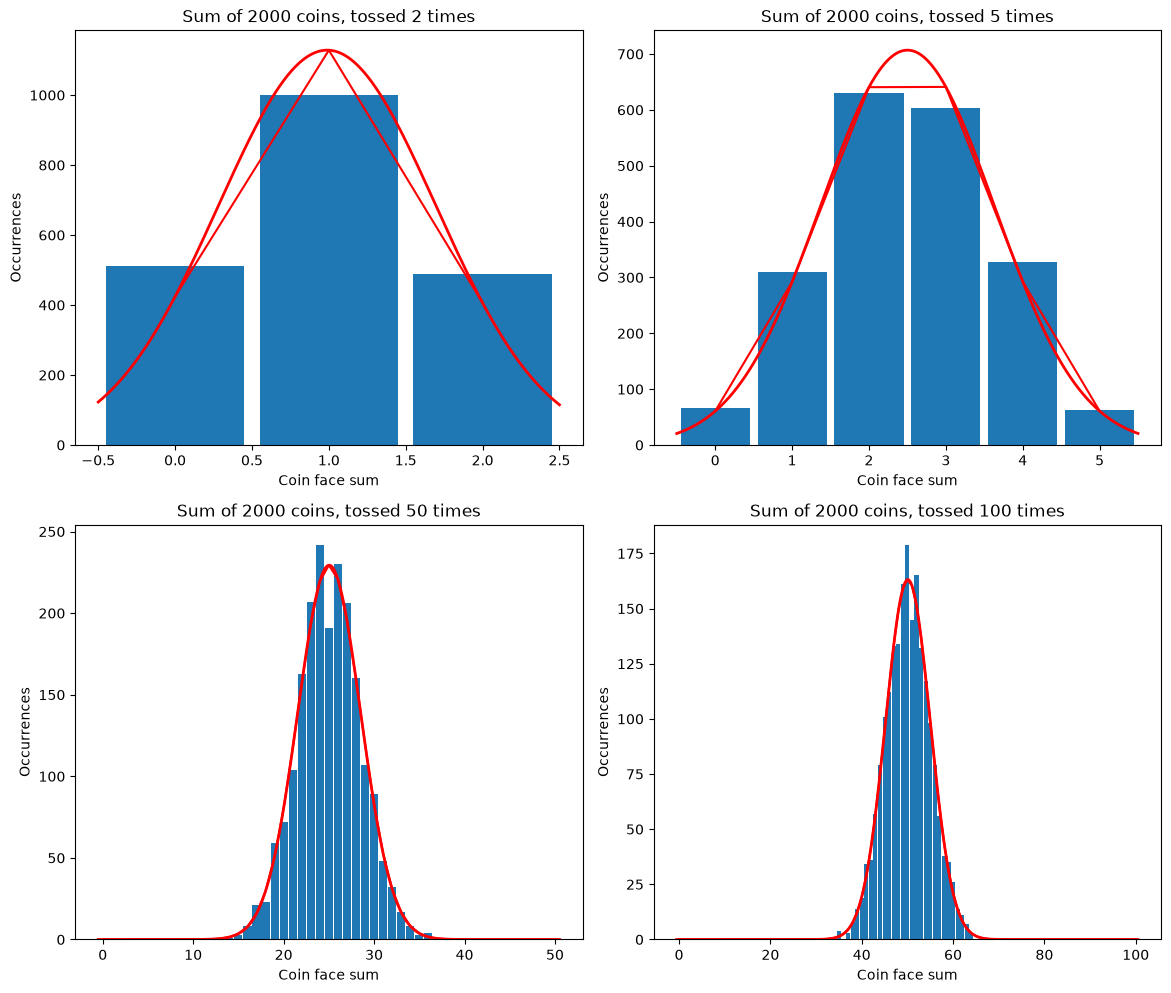

In [18]:
cm = 0.393701  # Umrechnung Zentimeter zu Zoll

Ncoins = 2000
Mtosses = np.array([2, 5, 50, 100])

fig = plt.figure(figsize=(30 * cm, 25.5 * cm))

for i in range(len(Mtosses)):
    s = np.zeros(Ncoins, dtype=int)

    for j in range(Mtosses[i]):
        s += np.random.randint(0, 2, Ncoins)

    # Histogramm
    bin_edges = np.arange(0, Mtosses[i] + 2) - 0.5
    hist, _ = np.histogram(s, bins=bin_edges)
    bin_centers = np.arange(0, Mtosses[i] + 1)

    # Mittelwert und Varianz
    mean = np.mean(s)
    var = np.var(s)

    # Viele x-Werte für eine glatte Gausskurve
    x_gauss = np.linspace(
        bin_edges[0],
        bin_edges[-1],
        1000
    )

    gauss = (
        Ncoins
        / np.sqrt(2 * np.pi * var)
        * np.exp(-(x_gauss - mean) ** 2 / (2 * var))
    )

    ax = fig.add_subplot(2, 2, i + 1)

    ax.bar(
        bin_centers,
        hist,
        width=0.9
    )

    ax.plot(
        x_gauss,
        gauss,
        color="r",
        linewidth=2
    )
    cal = Ncoins / np.sqrt(2 * np.pi * var) * np.exp(-(bin_centers - mean)**2 / (2 * var))

    ax.plot(bin_centers, cal, color='r')


    ax.set_xlabel("Coin face sum")
    ax.set_ylabel("Occurrences")
    ax.set_title(
        "Sum of {:d} coins, tossed {:d} times".format(
            Ncoins,
            Mtosses[i]
        )
    )

fig.tight_layout()
plt.show()

Ex 04


Error mean

$
    SEM = \frac{s}{\sqrt{N}}
$

s = Standartabweichung der Messwerte

N = Anzahl der Messwerte

In [19]:
cm = 0.393701  # Umrechnung Zoll zu Centimeter

# Logarithmischer Bereich von 10 bis len(data): Das sind die verschiedenen n (Anzahl berücksichtiger Punkte)
# dtype = int ist notwendig, damit wir diese Zahlen gleich als Arrayindizes verwenden können.
n_points = np.logspace(1, np.log10(len(data)), 100, dtype=int)

# Initialisiere Arrays, in denen die berechneten Werte für jedes n gespeichert werden
mean_n = np.zeros(len(n_points))
std_n = np.zeros(len(n_points))
error_mean = np.zeros(len(n_points))

# Berechne Mittelwert, Standardabweichung und Fehler des Mittelwerts für jedes n.
for i, n in enumerate(n_points):
    mean_n[i] = np.mean(data[:n])
    std_n[i] = np.std(data[:n])
    error_mean[i] = np.std(data[:n]) / np.sqrt(n)

# Ergebnis Plotten
fig = plt.figure(figsize=(30*cm, 25.5*cm))
ax = fig.add_subplot(2, 2, 1)
ax.semilogx(n_points, mean_n)
ax.set_xlabel('Anzahl Punkte N')
ax.set_ylabel(r'Mittelwert $\bar{x}_n$')

ax = fig.add_subplot(2, 2, 2)
ax.semilogx(n_points, std_n)
ax.set_xlabel('Anzahl Punkte N')
ax.set_ylabel(r'Standardabweichung $\sigma$')

ax = fig.add_subplot(2, 2, 3)
ax.semilogx(n_points, error_mean, label='Erwarteter Fehler')
ax.semilogx(n_points, np.abs(mean_n - mean_n[-1]),label='Effektiver Fehler') #mean_n[-1] ist der mean der ganz am Schluss ist
ax.set_xlabel('Anzahl Punkte N')
ax.set_ylabel(r'Fehler des Mittelwerts $\sigma_{\bar{x}_n}$')
ax.legend()

NameError: name 'data' is not defined

In [20]:
cm = 0.393701  # Umrechnung Zoll zu Zentimeter

# Liste der betrachteten n
n_points_list = np.array([10, 100, 1000, 10000])

fig = plt.figure(figsize=(30*cm, 25.5*cm))
binsize = 0.5

# Wir erzeugen die Histogramme und Plots für die verschiedenen n in einer for-Schleife, da
# der Code immer der gleiche ist.
for i, n_points in enumerate(n_points_list):
    # Mittelwert und Fehler des Mittelwerts berechnen
    mean = np.mean(data[:n_points])
    error_mean = np.std(data[:n_points]) / np.sqrt(n_points)
    
    # Histogramm erzeugen
    bin_edges = np.arange(np.min(data[:n_points]), np.max(data[:n_points])+1, binsize)
    bin_centers = bin_edges[:-1] + 0.5 * binsize
    hist, _ = np.histogram(data[:n_points], bin_edges)
    
    # Plotten
    ax = fig.add_subplot(2, 2, i+1)
    ax.bar(bin_centers, hist, width=0.8*binsize)
    ax.axvline(mean, color='r')
    ax.axvline(mean-error_mean, color='r', linestyle='--')
    ax.axvline(mean+error_mean, color='r', linestyle='--')
    ax.set_xlabel('Bins')
    ax.set_ylabel('Anzahl Ereignisse')
    ax.set_title('Anzahl Datenpunkte: {:.0f}'.format(n_points))

NameError: name 'data' is not defined

<Figure size 1181.1x1003.94 with 0 Axes>

Der Mittelwert ist gegeben durch

$$\bar{x} = \frac{1}{N} \sum_{i=1}^{N} x_i.$$

Jeder Datenpunkt $x_i$ ist eine Unabhähngige Variable, d.h. die Varianz des Mittelwerts ist

$$\sigma_{\bar{x}}^2 = \sum_{i=1}^{N} \left(\frac{\partial\bar{x}}{\partial x_i}\right)^2 \sigma^2.$$

Die Ableitung nach dem $i$-ten Punkt ist 

$$\left(\frac{\partial\bar{x}}{\partial x_i}\right) = \frac{1}{N},$$

also haben wir

$$\sigma_{\bar{x}}^2 = \sum_{i=1}^{N} \left(\frac{\partial\bar{x}}{\partial x_i}\right)^2 \sigma^2 = \sum_{i=1}^{N} \frac{1}{N^2} \sigma^2 = \frac{\sigma^2}{N}$$

und somit wie erwartet

$$\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{N}}.$$

Gausche fehlervortpflanzung

$$\sigma_{\bar{x}}^2 = \sum_{i=1}^{N} \left(\frac{\partial\bar{x}}{\partial x_i}\right)^2 \sigma^2.$$

zum Beispiel Zentripedalkraft

$$\sigma_F=\sqrt{\left(\frac{\partial F}{\partial m}\right)^2\sigma_m^2 + \left(\frac{\partial F}{\partial v}\right)^2\sigma_v^2+\left(\frac{\partial F}{\partial R}\right)^2\sigma_R^2} \\
 = \sqrt{\frac{v^4}{R^2}\sigma_m^2 + \frac{4m^2v^2}{R^2}\sigma_v^2 + \frac{m^2v^4}{R^4}\sigma_R^2} \\
  = F_z\sqrt{\frac{1}{m^2}\sigma_m^2+\frac{4}{v^2}\sigma_v^2+\frac{1}{R^2}\sigma_R^2}$$



$\sigma_i$ ist aus einer liste oder ist gegeben

In [21]:
Fz = m * v**2 / R
sigma_F = Fz * np.sqrt(1 / m**2 * sigma_m**2 + 4 / v**2 * sigma_v**2)



f



NameError: name 'm' is not defined

xerr ist die verzerrung inr richting x, y nach y 

man hat $\sigma_v$ genommen weil auf der x achse die geschwindigkeit sit

Ex05


Als Referenz hier nochmal die Definition der Kovarianz aus der Vorlesung:

$$ \sigma_{xy}^2 = \mathrm{cov}(x, y) = \frac{1}{N} \sum_{i=1}^{N} (x_i - \bar{x}) (y_i - \bar{y}).$$

Für die covarianz kann man einfach

$$ \mathrm{np.cov(x, y)} = \left( \begin{matrix} \sigma_{xx}^2 & \sigma_{xy}^2 \\
                                                 \sigma_{yx}^2 & \sigma_{yy}^2 \end{matrix} \right). $$
verwenden um dann [0,1] um wie die koordinaten eingeben um die richtige covarianz zu bekommen

In [22]:
x = [i for i in range(10)]
y = [i for i in range(10,20)]
print(np.cov(x,y)[0,1])

9.166666666666666


Korrelationskoeffizienten ist:
$$\rho_{xy} = \frac{\mathrm{cov}(x, y)}{\sigma_x \sigma_y}.$$

In [23]:
print(np.cov(x,y)[0,1]/np.sqrt(np.cov(x,x)[0,0] * np.cov(y,y)[0,0]))

C = np.cov(x,y)

rho = C[0,1] / np.sqrt(C[0,0] * C[1,1])
print(rho)

rho = np.corrcoef(x,y)[0,1]
print(rho)

1.0
1.0
0.9999999999999999


Die Autokovarianz 

$$R_{xx}(\Delta i) = \frac{1}{N - \Delta i} \sum_{i=0}^{N - \Delta i - 1} \left(x[i] - \bar{x}\right) \left(x[i + \Delta i] - \bar{x}\right)$$

In [26]:
def auto_covariance_fast(x, delta):
    # Den Fall delta = 0 müssen wir separat behandeln, weil x[:-0] ein leeres Array gibt.
    if delta == 0:
        autocov = np.var(x)
    else:
        N = len(x)
    
        # Wir subtrahieren erst den Mittelwert vom ganzen Array
        x_mean = np.mean(x)
        x_residue = x - x_mean
        
        # Durch Array-Slicing erhalten wir die relevanten überlappenden Teilarrays, von denen wir
        # den Mittelwert subtrahieren. Da wir mit Numpy-Arrays arbeiten, wird die anschliessende
        # Multiplikation elementweise durchgeführt. Die Elemente des resultierenden Arrays werden
        # mit np.sum effizient aufsummiert.
        autocov = np.sum(x_residue[:-delta] * x_residue[delta:]) / (N - delta)
        
    return autocov

In [27]:
print(np.where(x - y < 0.00001, 0, x - y))
#oder
z = x -y
z[z < 1e-10] = 0

TypeError: unsupported operand type(s) for -: 'list' and 'list'

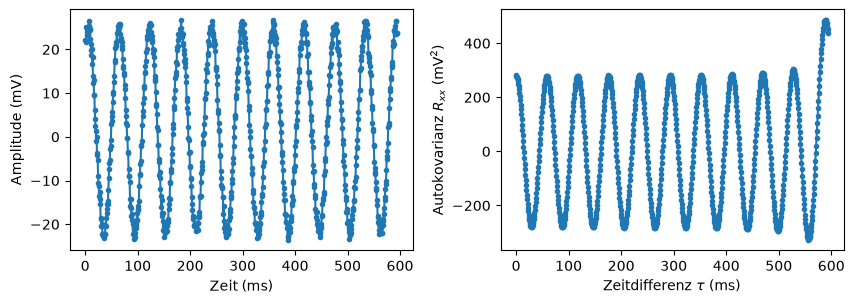

In [32]:
data = np.loadtxt('Ex05/signal_2.txt', comments='#')
t = data[:, 0]
amplitude = data[:, 1]
V = amplitude

# Autokovarianz
N = len(amplitude)  # Anzahl Datenpunkte
dt = t[1] - t[0]  # Zeitdifferenz zwischen zwei Datenpunkten
tau = np.arange(N-1) * dt  # Tau-Achse für die Autokovarianz <- das hier ist noch wichtig fürs verstaende
r_xx = np.zeros(N-1)
for delta in range(N-1):
    r_xx[delta] = auto_covariance_fast(amplitude, delta)

# Plotten
cm = 1 / 2.54
fig = plt.figure(figsize=(22*cm, 8*cm))
ax = fig.add_subplot(1, 2, 1)
ax.plot(t * 1e3, amplitude, '.-')
ax.set_xlabel('Zeit (ms)')
ax.set_ylabel('Amplitude (mV)')

ax = fig.add_subplot(1, 2, 2)
ax.plot(tau * 1e3, r_xx, '.-')
ax.set_xlabel('Zeitdifferenz $\\tau$ (ms)')
ax.set_ylabel('Autokovarianz $R_{xx}$ (mV$^2$)')

fig.tight_layout()

Ex06 Fourriertransformation

$$x(t) = \sum_{n=0}^{\infty} a_n \sin(2\pi f_n t + \phi_n),$$


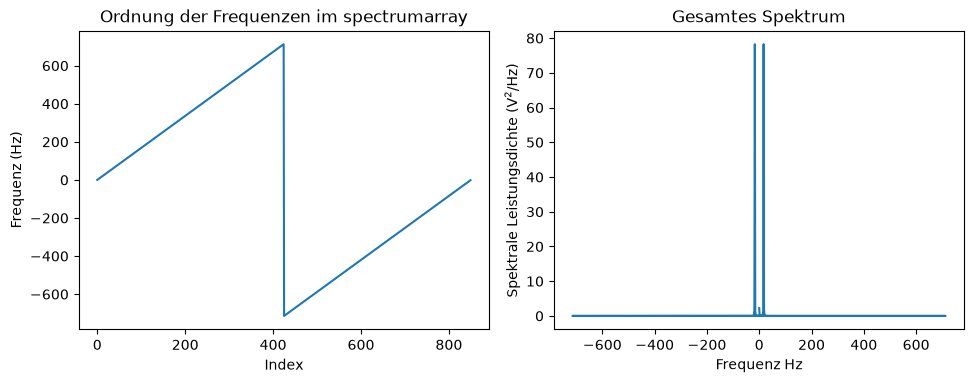

In [33]:
N = len(t)
dt = t[1] - t[0]

# Berechnen der geordneten Frequenzachse
f = np.fft.fftfreq(N, dt)
# Berechnen der Fouriertransformation
spectrum = np.fft.fft(V)
# Berechnen der spektralen Leistungsdichte 
psd = dt / N * np.abs(spectrum)**2 #das ist das schwierige was man genau daraus berechnen möchte

#es ist immer aus np.fft.fft(V)**2 und dann noch ein normierugsfaktor der man wissen muss errarten kann kommt darauf an was man möchte


cm = 1 / 2.54
fig = plt.figure(figsize=(25*cm, 10*cm))
ax = fig.add_subplot(1, 2, 1)
ax.plot(f)
ax.set_xlabel('Index')
ax.set_ylabel('Frequenz (Hz)')
ax.set_title('Ordnung der Frequenzen im spectrumarray')

ax = fig.add_subplot(1, 2, 2)
ax.plot(f, psd)
ax.set_xlabel('Frequenz Hz')
ax.set_ylabel(r'Spektrale Leistungsdichte (V$^2$/Hz)')
ax.set_title('Gesamtes Spektrum')

fig.tight_layout()

In [34]:
import numpy as np

dt = 0.01
N = 1000

t = np.arange(N) * dt

V = (
    3*np.sin(2*np.pi*5*t) +
    1.5*np.sin(2*np.pi*12*t) +
    0.8*np.sin(2*np.pi*18*t) +
    0.5*np.sin(2*np.pi*123*t) +
    0.3*np.random.randn(N) 
)




Text(0, 0.5, 'Spektrale Leistungsdichte (V$^2$/Hz)')

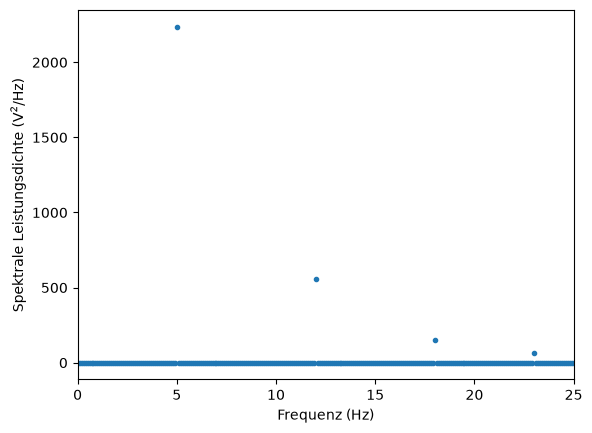

In [35]:
f = np.fft.fftfreq(N, dt)

spectrum = np.fft.fft(V)

psd = dt / N * np.abs(spectrum)**2

f_s = 1/dt 

Md = N * dt

deltaf = f_s/N #oder

deltaf_2 = 1/Md

power = np.abs(spectrum)**2 / N
# Plotten
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(f, power,'.')
ax.set_xlim(0, 25)
ax.set_xlabel('Frequenz (Hz)')

ax.set_ylabel('Spektrale Leistungsdichte (V$^2$/Hz)')



Abtastfrequenz:    100.000 Hz
Messdauer:         10.000 s
Frequenzauflösung: 0.100 Hz

Gefundene Peaks:
------------------------------------------
Frequenz [Hz] | Amplitude | Leistung
------------------------------------------
        5.000 |    2.9914 |   4.4741
       12.000 |    1.4952 |   1.1178
       18.000 |    0.7858 |   0.3088
       23.000 |    0.4967 |   0.1234


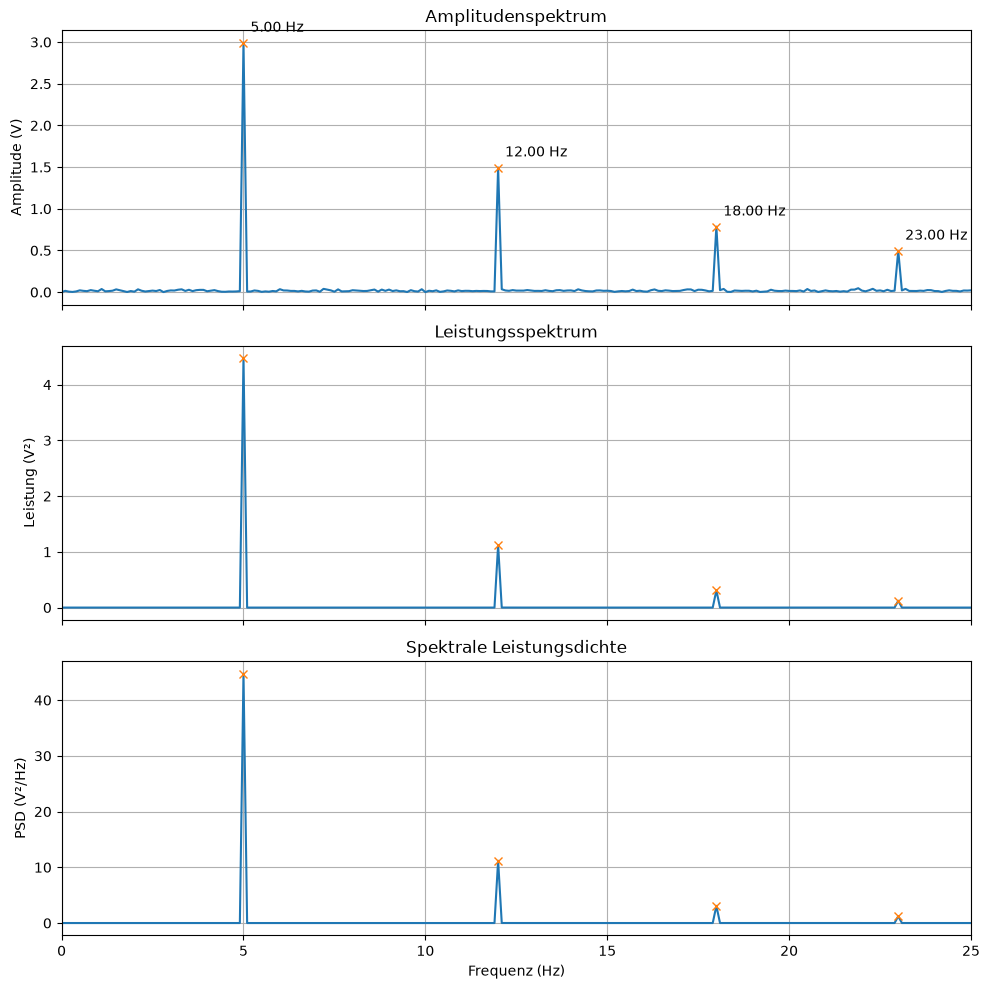

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Grundgrößen
# -------------------------------------------------
N = len(t)
dt = t[1] - t[0]

fs = 1 / dt
T = N * dt
delta_f = fs / N

# Gleichanteil entfernen
V_clean = V - np.mean(V)

# -------------------------------------------------
# FFT für reale Signale
# -------------------------------------------------
f = np.fft.rfftfreq(N, dt)
spectrum = np.fft.rfft(V_clean)

# -------------------------------------------------
# Amplitudenspektrum
# -------------------------------------------------
amplitude = np.abs(spectrum) / N

if N % 2 == 0:
    amplitude[1:-1] *= 2
else:
    amplitude[1:] *= 2

# -------------------------------------------------
# Leistungsspektrum
# -------------------------------------------------
power = np.abs(spectrum)**2 / N**2

if N % 2 == 0:
    power[1:-1] *= 2
else:
    power[1:] *= 2

# -------------------------------------------------
# PSD
# -------------------------------------------------
psd = dt / N * np.abs(spectrum)**2

if N % 2 == 0:
    psd[1:-1] *= 2
else:
    psd[1:] *= 2

# -------------------------------------------------
# Peaks nur mit NumPy finden
# -------------------------------------------------

# Lokale Maxima:
# Wert ist größer als linker und rechter Nachbar
peak_mask = (
    (amplitude[1:-1] > amplitude[:-2]) &
    (amplitude[1:-1] > amplitude[2:])
)

# +1, weil wir bei amplitude[1:-1] gestartet haben
peak_indices = np.where(peak_mask)[0] + 1

# Kleine Rausch-Peaks herausfiltern
threshold = 0.05 * np.max(amplitude)

peak_indices = peak_indices[
    amplitude[peak_indices] > threshold
]

# Nach Höhe sortieren
order = np.argsort(amplitude[peak_indices])[::-1]
peak_indices = peak_indices[order]

# -------------------------------------------------
# Peaks ausgeben
# -------------------------------------------------
print(f"Abtastfrequenz:    {fs:.3f} Hz")
print(f"Messdauer:         {T:.3f} s")
print(f"Frequenzauflösung: {delta_f:.3f} Hz")
print()

print("Gefundene Peaks:")
print("------------------------------------------")
print("Frequenz [Hz] | Amplitude | Leistung")
print("------------------------------------------")

for index in peak_indices:
    print(
        f"{f[index]:13.3f} | "
        f"{amplitude[index]:9.4f} | "
        f"{power[index]:8.4f}"
    )

# -------------------------------------------------
# Plotten
# -------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axes[0].plot(f, amplitude)
axes[0].plot(
    f[peak_indices],
    amplitude[peak_indices],
    "x"
)
axes[0].set_ylabel("Amplitude (V)")
axes[0].set_title("Amplitudenspektrum")
axes[0].grid(True)

for index in peak_indices:
    axes[0].annotate(
        f"{f[index]:.2f} Hz",
        (f[index], amplitude[index]),
        xytext=(5, 8),
        textcoords="offset points"
    )

axes[1].plot(f, power)
axes[1].plot(
    f[peak_indices],
    power[peak_indices],
    "x"
)
axes[1].set_ylabel("Leistung (V²)")
axes[1].set_title("Leistungsspektrum")
axes[1].grid(True)

axes[2].plot(f, psd)
axes[2].plot(
    f[peak_indices],
    psd[peak_indices],
    "x"
)
axes[2].set_xlabel("Frequenz (Hz)")
axes[2].set_ylabel("PSD (V²/Hz)")
axes[2].set_title("Spektrale Leistungsdichte")
axes[2].grid(True)

axes[2].set_xlim(0, 25)

fig.tight_layout()
plt.show()


Nyquist-Frequenz

das ist die höchte darstellbare frequenz
$$f_N = \frac{f_s}{2}$$

die Frequenzauflösung ist 
$$f_a=\frac{1}{\Delta T}$$

In [38]:
np.argmax() #kann man die peaks finden
np.argsort(amplitude)[-3:] #die drei höchsten peaks finden

TypeError: argmax() missing 1 required positional argument: 'a'

Die Amplitude ist eine Frage der Normierung
 {mache hier beispiele}

In [39]:
N = len(f)
amplitudes = np.zeros(int(N/2))
for i in range(1, len(amplitudes), 2):
    amplitudes[i] = 4 / (np.pi * i)

#beispiel um das mit dem Viereck darzustellen

Ex07

In [40]:
import numpy as np
from numpy.fft import fftfreq, fft, ifft
import matplotlib.pyplot as plt

In [41]:
def moving_average(x, delta, edges='repeat'):
    '''Calculate moving average of data array x. Average goes from i-delta to i+delta for every i.
    The argument edges determines how the edge of the array is treated. Options are:
        'repeat': First or last value is repeated beyond array. Output array has same length as input array.
        'cut': Input array is not extended for averaging. Output array has length N-2*delta, where N is len(x).
        'wrap': Input array wraps around for averaging. Output array has same length as input array.'''
    
    N = len(x)
    
    filtered_array = np.zeros(N)
    
    if edges == 'repeat':
        # Original data starts at index delta, stops at delta+N-1
        padded_array = np.concatenate([
            np.ones(delta) * x[0],  # repeat first value at start
            x,
            np.ones(delta) * x[-1]  # repeat last value at end
        ])
    elif edges == 'cut':
        # We pad with zeros to be able to treat this case the same as the others while averaging.
        # We need to cut the start and end of the array before returning it.
        padded_array = np.concatenate([
            np.zeros(delta),
            x,
            np.zeros(delta)
        ])
    elif edges == 'wrap':
        padded_array = np.concatenate([
            x[-delta:],
            x,
            x[:delta]
        ])
    else:
        raise ValueError('Invalid argument edges="{}"'.format(edges))

    # Calculate moving average
    for i in range(N):
        filtered_array[i] = np.mean(padded_array[i:i+2*delta])

    # Cut invalid parts in case edges='cut'
    if edges == 'cut':
        filtered_array = filtered_array[delta:-delta]
        
    return filtered_array

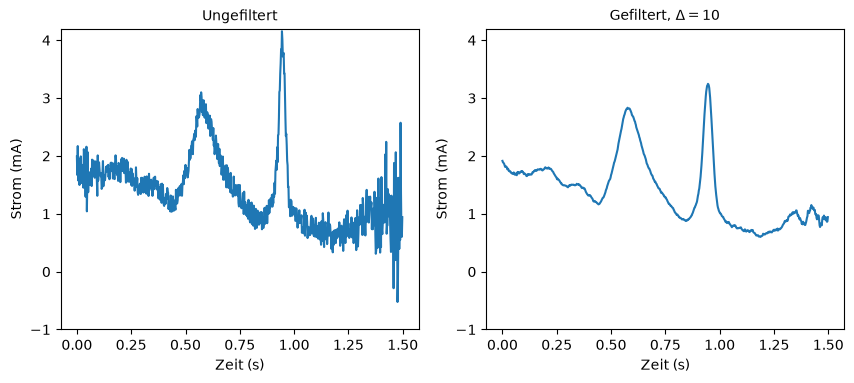

In [42]:
data = np.loadtxt('Ex07/peaks.txt')
t = data[:, 0]
signal = data[:, 1]

# Glätten
delta = 10 #je höher das delta ist ums gletter wird die Funktion das heisst die Peaks sind dan weniger gut zu erkennen das sie eine art durchschnitt abgelenkt werden
filtered_signal = moving_average(signal, delta)

# Plotten
cm = 1 / 2.54

fig = plt.figure(figsize=(22 * cm, 10 * cm))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(t, signal, '-')
ax1.set_title('Ungefiltert', size=10)

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(t, filtered_signal, '-')
ax2.set_title('Gefiltert, $\\Delta = {}$'.format(delta), size=10)

for ax in (ax1, ax2):
    ax.set_xlabel('Zeit (s)')
    ax.set_ylabel('Strom (mA)')
    ax.set_ylim(-1, 4.2)

fig.tight_layout()

Das glätten kann auch verwenden werden bevor man fourier anwendet dabei werden die frequenzen die gross genug sind heurausgefiltert.(macht Sinn das es die Frequenzen sind die am meisten vom Glätten verändert werden)

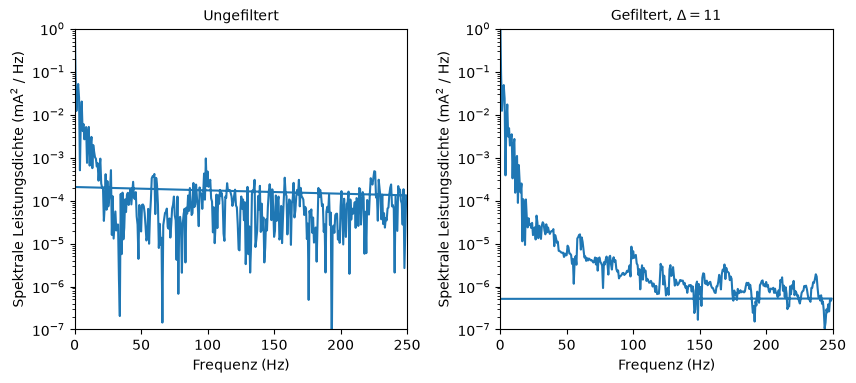

In [43]:
N = len(signal)
dt = t[1] - t[0]

# Berechnen der Spectralen Leistungsdichte des orginal Signals
frequency = fftfreq(N, dt)
spectrum = fft(signal)
psd = dt / N * np.abs(spectrum)**2

# Berechnen der PSD des gefilterten Signals.
delta = 11

filtered_signal = moving_average(signal, delta)
filtered_spectrum = fft(filtered_signal)
filtered_psd = dt / N * np.abs(filtered_spectrum)**2

# Plotten
cm = 1 / 2.54

fig = plt.figure(figsize=(22 * cm, 10 * cm))

ax1 = fig.add_subplot(1, 2, 1)
ax1.semilogy(frequency, psd, '-')
ax1.set_title('Ungefiltert', size=10)

ax2 = fig.add_subplot(1, 2, 2)
ax2.semilogy(frequency, filtered_psd, '-')
ax2.set_title('Gefiltert, $\\Delta = {}$'.format(delta), size=10)

for ax in (ax1, ax2):
    ax.set_xlabel('Frequenz (Hz)')
    ax.set_ylabel('Spektrale Leistungsdichte (mA$^2$ / Hz)')
    ax.set_ylim(1e-7, 1)
    ax.set_xlim(0,  250)

fig.tight_layout()

Diese Funktion glättet den Array auf verschiedene Art un weise

In diesem Beispiel werdet die Liste gespielgelt und der kleinere teil gekürzt das ist eine lustige art es zu machen man kann es aber auch in mehreren LIniean machen ist aber nicht so cool

In [44]:
data = np.loadtxt('Ex07/autocorrelation_laser.txt')
t = data[:, 0] * 1e-12  # in ps abgespeichert. Wir konvertieren in s
signal = data[:, 1]

## Um die PSD zu berechnen, müssen wir zuerst die Autokorrelation symmetrisieren:
pre_signal = signal[t<0]
post_signal = signal[t>0]
t_sym = t[t>0][:min(len(post_signal),len(pre_signal))]
symmetrized_signal = (np.flip(pre_signal[-min(len(post_signal),len(pre_signal)):]) + post_signal[:min(len(post_signal),len(pre_signal))])/2
# (x(-t) + x(t)) /2 das min kommt daher weil man die kleinere länge nimmt. Sonst fehler
# Zeitauflösung und Länge des Signals berechnen
dt = t[1] - t[0]
N = len(t_sym)

# Spektrale Leistungsdichte
psd = fft(symmetrized_signal)
frequency = fftfreq(N, d=dt)

/home/ukas_engis/lukas/venv/.myvenv/lib/python3.12/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ukas_engis/lukas/venv/.myvenv/lib/python3.12/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


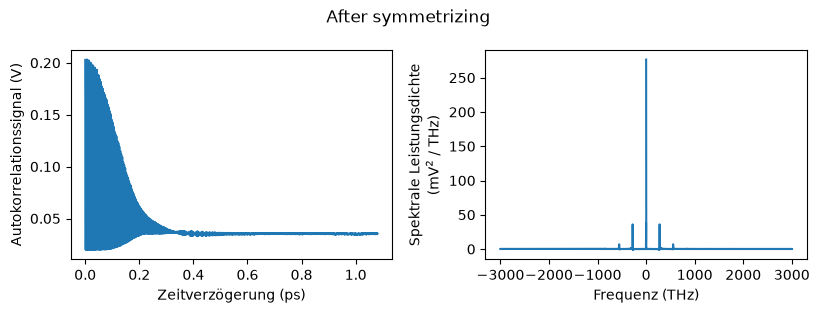

In [20]:
cm = 1 / 2.54

fig = plt.figure(figsize=(21 * cm, 8 * cm))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(t_sym * 1e12, symmetrized_signal, '-')
ax1.set_xlabel('Zeitverzögerung (ps)')
ax1.set_ylabel('Autokorrelationssignal (V)')

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(frequency / 1e12, psd, '-')
ax2.set_xlabel('Frequenz (THz)')
ax2.set_ylabel('Spektrale Leistungsdichte\n(mV$^2$ / THz)')
# ax2.set_yscale('log')
fig.suptitle("After symmetrizing")
fig.tight_layout()

da es einen Peak bei 0 hat ist damit zu deuten das es einen konstanten offset hat das ist bei realen daten zu erkenen da die nicht genau bei null ihren ursprung haben $x^0 = 1$

/home/ukas_engis/lukas/schule/DA/test/aufgaben/.myvenv/lib/python3.12/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ukas_engis/lukas/schule/DA/test/aufgaben/.myvenv/lib/python3.12/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


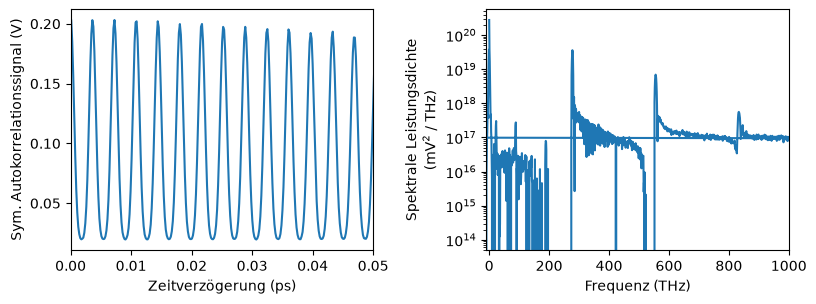

In [45]:
cm = 1 / 2.54

fig = plt.figure(figsize=(21 * cm, 8 * cm))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(t_sym * 1e12, symmetrized_signal, '-')
ax1.set_xlabel('Zeitverzögerung (ps)')
ax1.set_ylabel('Sym. Autokorrelationssignal (V)')

ax1.set_xlim(0, 0.05)


ax2 = fig.add_subplot(1, 2, 2)
ax2.semilogy(frequency / 1e12, psd * 1e12 * 1e6, '-')
ax2.set_xlabel('Frequenz (THz)')
ax2.set_ylabel('Spektrale Leistungsdichte\n(mV$^2$ / THz)')

ax2.set_xlim(-10, 1000)
# ax2.set_ylim(0, 100)

fig.tight_layout()

Im oberen PLot werden die die dominanten endlichen Frquqnzen sichtbar mit der hilfe des logarythmischen plottens. 280Hz 
Ich sehe es wie eine art zoom

np.fft.ifft(psd)
 ist eine Fourier Rücktransformation es gitb einen realen und imaginären teil.
Falls der imaginäre Teil = 0 ist dann handelt es sich um eine hermitisch symmetrishces Signal

Text(0, 0.5, 'Rekonstruiertes Signal U(t) (V)')

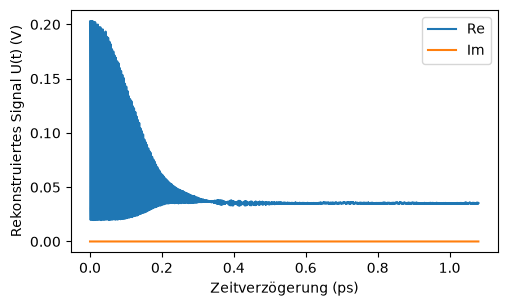

In [46]:
signal_reconstruct = ifft(psd)

cm = 1 / 2.54
fig = plt.figure(figsize=(14 * cm, 8 * cm))

ax1 = fig.add_subplot(1, 1, 1)
# Wir plotten Realteil und Imaginärteil des rekonstruierten Signals, um zu überprüfen,
# dass das Signal rein reell ist.
ax1.plot(t_sym * 1e12, np.real(signal_reconstruct), '-', label='Re')
ax1.plot(t_sym * 1e12, np.imag(signal_reconstruct), '-', label='Im')
ax1.legend()
ax1.set_xlabel('Zeitverzögerung (ps)')
ax1.set_ylabel('Rekonstruiertes Signal U(t) (V)')

Hier nimmt man jede frequenz heraus die nicht in dem intervall ist das vorgegeben ist danach wird es wieder mit ifft zurück trnasformiert

In [47]:
def filter_signal(t, signal, f_min, f_max):
    '''Filter a signal by keeping only Fourier components between f_min and f_max.'''
    # Zeitauflösung und Anzahl Punkte im Signal
    dt = t[1] - t[0]
    N = len(t)
    
    # Fouriertransformation
    frequency = fftfreq(N, d=dt)
    spectrum = fft(signal)
    


    # In einer for-Schleife werden alle Frequenzen durchlaufen. Wenn die Frequenz
    # ausserhalb des gewählten Bereichs liegt, wird die entsprechende Amplitude
    # auf Null gesetzt.
    for i in range(len(frequency)):
        if abs(frequency[i]) < f_min or f_max < abs(frequency[i]):
            spectrum[i] = 0
    
    # Rücktransformation des gefilterten Spektrums. Der Imaginärteil ist Null und kann
    # verworfen werden.
    filtered_signal = np.real(ifft(spectrum))
    return filtered_signal

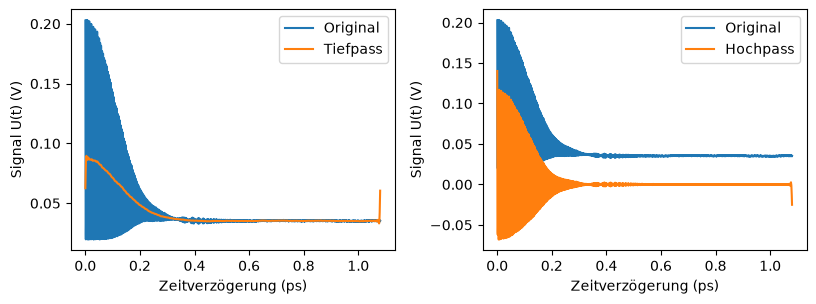

In [24]:
cutoff = 150e12
f_ny = 1 / (2 * (t[1] - t[0]))

filtered_lowpass = filter_signal(t_sym, symmetrized_signal, 0, cutoff)
filtered_highpass = filter_signal(t_sym, symmetrized_signal, cutoff, f_ny)

cm = 1 / 2.54
fig = plt.figure(figsize=(21 * cm, 8 * cm))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(t_sym * 1e12, symmetrized_signal, '-', label='Original')
ax1.plot(t_sym * 1e12, filtered_lowpass, '-', label='Tiefpass')
ax1.legend()
ax1.set_xlabel('Zeitverzögerung (ps)')
ax1.set_ylabel('Signal U(t) (V)')

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(t_sym * 1e12, symmetrized_signal, '-', label='Original')
ax2.plot(t_sym * 1e12, filtered_highpass, '-', label='Hochpass')
ax2.legend()
ax2.set_xlabel('Zeitverzögerung (ps)')
ax2.set_ylabel('Signal U(t) (V)')
fig.tight_layout()

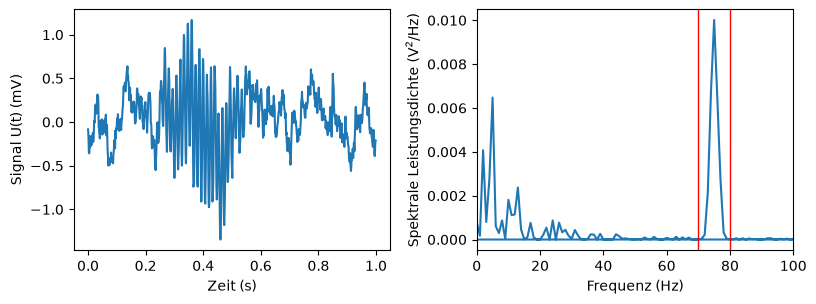

In [48]:
# Daten laden
data = np.loadtxt('Ex07/noisy_pulse.txt')
t = data[:, 0]
signal = data[:, 1]

# Fouriertransformation und spektrale Leistungsdichte
N = len(t)
dt = t[1] - t[0]

frequency = fftfreq(N, dt)
spectrum = fft(signal)
psd = dt / N * np.abs(spectrum)**2


# Daten Plotten
cm = 1 / 2.54

fig = plt.figure(figsize=(21 * cm, 8 * cm))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(t, signal, '-')
ax1.set_xlabel('Zeit (s)')
ax1.set_ylabel('Signal U(t) (mV)')

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(frequency, psd, '-')
ax2.set_xlabel('Frequenz (Hz)')
ax2.set_ylabel('Spektrale Leistungsdichte (V$^2$/Hz)')
ax2.set_xlim(0, 100)

ax2.axvline(70, color='r', linewidth=1)
ax2.axvline(80, color='r', linewidth=1)

fig.tight_layout()

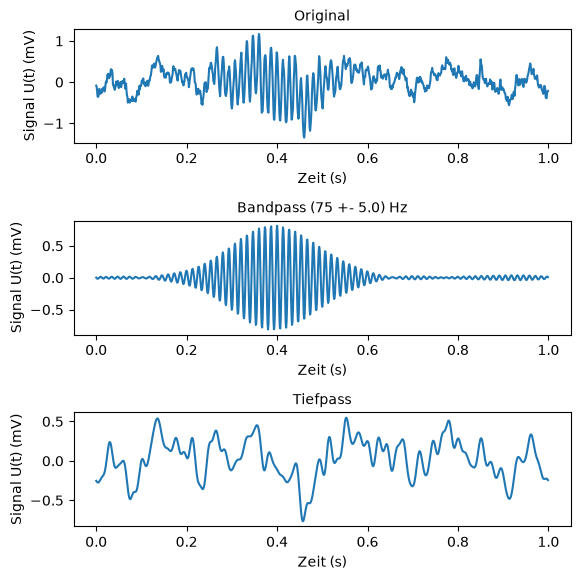

In [49]:
center = 75
width = 10
bandpass_signal = filter_signal(t, signal, center - width / 2, center + width / 2)
lowpass_signal = filter_signal(t, signal, 0, 60)

cm = 1 / 2.54

fig = plt.figure(figsize=(15 * cm, 15 * cm))

ax1 = fig.add_subplot(3, 1, 1)
ax1.plot(t, signal, '-')
ax1.set_xlabel('Zeit (s)')
ax1.set_ylabel('Signal U(t) (mV)')
ax1.set_title('Original', size=10)

ax2 = fig.add_subplot(3, 1, 2)
ax2.plot(t, bandpass_signal, '-')
ax2.set_xlabel('Zeit (s)')
ax2.set_ylabel('Signal U(t) (mV)')
ax2.set_title('Bandpass ({} +- {}) Hz'.format(center, width/2), size=10)

ax3 = fig.add_subplot(3, 1, 3)
ax3.plot(t, lowpass_signal, '-')
ax3.set_xlabel('Zeit (s)')
ax3.set_ylabel('Signal U(t) (mV)')
ax3.set_title('Tiefpass', size=10)

fig.tight_layout()

hier hat man erkennt das bei ungefähr 75 ein störfrequenz ist dann hat mit sie heruasgefiltert und man kann es nun wieder normal berabeiten ohne die störtung noch gut$


Ex08 ist eigentlich simple wahrscheinlihckeit ein bisschen darstellen und eifache funktionene und so wenn du das hier in zukunft sieht schaue trotzdem noch Momente und so.

Probality mass Function
Alles was diese Funktion macht, ist Datenmengen nehmen und diese als wahrscheinlichkeit darstellen in einer Baklendiagram

In [50]:
def PMF(data, resolution):
    # Definieren der Bins und Berechnen des Histogramms
    # Wir addieren resolution / 1000 zur Obergrenze, um sicherzustellen, dass der letzte Wert auch im Array ist.
    bin_centers = np.arange(np.min(data), np.max(data) + resolution / 1000, resolution)
    bin_edges = np.linspace(bin_centers[0] - resolution / 2,
                            bin_centers[-1] + resolution / 2,
                            len(bin_centers) + 1)
    
    hist, _ = np.histogram(data, bin_edges)
    
    # Normieren
    px = hist / np.sum(hist)
    
    return bin_centers, px

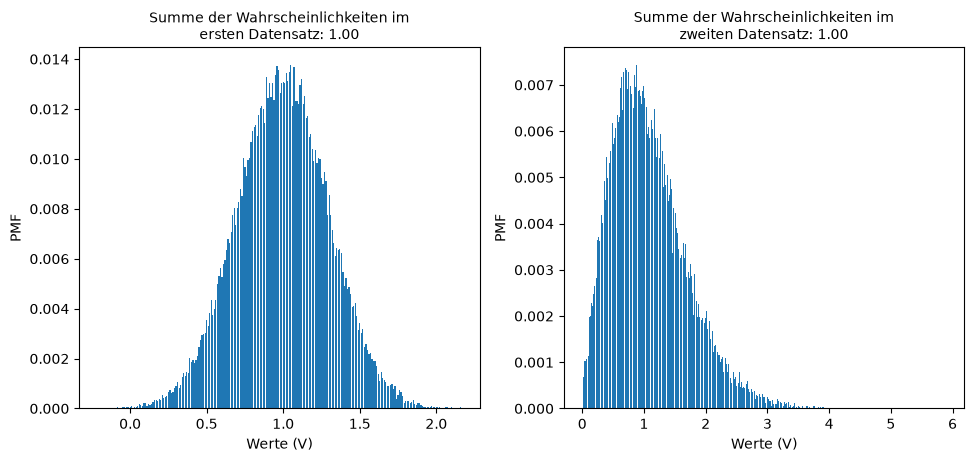

In [52]:
data = np.loadtxt('Ex08/Voltages.txt', skiprows=1)
time = data[0, :]
V1 = data[1, :]
V2 = data[2, :]
resolution = 1e-2

cm = 1 / 2.54
fig = plt.figure(figsize=(25*cm, 12*cm))

ax = fig.add_subplot(1, 2, 1)
x, px = PMF(V1, resolution)
ax.bar(x, px, resolution*0.8)
ax.set_xlabel('Werte (V)')
ax.set_ylabel('PMF')
ax.set_title('Summe der Wahrscheinlichkeiten im\nersten Datensatz: {:.2f}'.format(np.sum(px)), size=10)

ax = fig.add_subplot(1, 2, 2)
x, px = PMF(V2, resolution)
ax.bar(x, px, resolution*0.8)
ax.set_xlabel('Werte (V)')
ax.set_ylabel('PMF')
ax.set_title('Summe der Wahrscheinlichkeiten im\nzweiten Datensatz: {:.2f}'.format(np.sum(px)), size=10)
#ax.set_xlim(0.8,1.2)

fig.tight_layout()

Ein paar FUnktionionen

In [53]:
def mode(data, resolution):
    # Berechnen der PMF
    x, px = PMF(data, resolution)
    # Der Wahrscheinlichste Wert ist derjenige, bei dem die PMF ein Maximum hat. 
    return x[np.argmax(px)]



def mode_manual(data, resolution):
    # Berechnen der PMF
    x, px = PMF(data, resolution)
    
    max_x = 0
    max_val = px[0]
    # Iteration durch das Array, um die höchste Wahrscheindlichkeit und den dazugehörigen Wert zu finden. 
    for i, val in enumerate(px):
        if val > max_val:
            max_val = val
            max_x = x[i]
            
    return max_x

# np.median(data)

def median(data, resolution):
    # Wir berechnen zuerst die PMF
    x, px = PMF(data, resolution)
    # Wir summieren die Wahrscheinlichkeiten auf, bis wir 50% erreicht haben, der Median entspricht
    # dem Wert bei 50%.
    curr_sum = 0
    for i in range(len(x)):
        curr_sum += px[i]
        if curr_sum >= 0.5:
            break
    return x[i]


def mediansort(data):
    # Wir sortieren die Daten, der Median entspricht dem Datenpunkt in der Mitte.
    data_sorted = np.sort(data)
    if len(data) % 2 != 0:
        median = data_sorted[len(data)//2]
    # Bei gerader Anzahl Datenpunkten mitteln wir über die beiden benachbarten Punkte.
    else:
        median = (data_sorted[len(data)//2] + data_sorted[len(data)//2 - 1]) / 2
    return median

In der Grafik

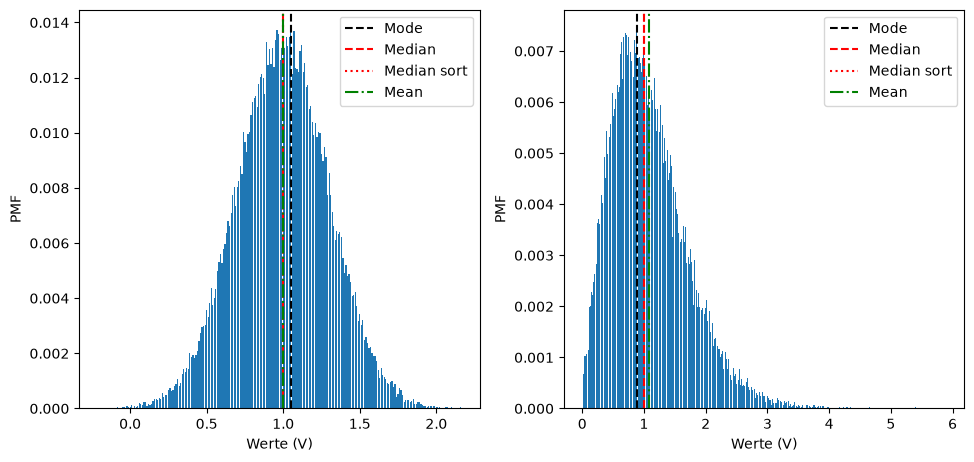

In [54]:
fig = plt.figure(figsize=(25*cm, 12*cm))

x, px = PMF(V1, resolution)

ax = fig.add_subplot(1,2,1)
ax.bar(x, px, resolution*0.8)

ax.axvline(mode(V1, resolution), color='k', linestyle='--', label='Mode')
ax.axvline(median(V1, resolution), color='r', linestyle='--', label='Median')
ax.axvline(mediansort(V1), color='r', linestyle=':', label='Median sort')
ax.axvline(np.mean(V1), color='g', linestyle='-.', label='Mean')

ax.set_xlabel('Werte (V)')
ax.set_ylabel('PMF')
#ax.set_xlim(0.975,1.02)
ax.legend()


x, px = PMF(V2, resolution)

ax = fig.add_subplot(1,2,2)
ax.bar(x, px, resolution*0.8)

ax.axvline(mode(V2, resolution), color='k', linestyle='--', label='Mode')
ax.axvline(median(V2, resolution), color='r', linestyle='--', label='Median')
ax.axvline(mediansort(V2), color='r', linestyle=':', label='Median sort')
ax.axvline(np.mean(V2), color='g', linestyle='-.', label='Mean')

ax.set_xlabel('Werte (V)')
ax.set_ylabel('PMF')
#ax.set_xlim(0.975,1.02)
ax.legend()

fig.tight_layout()

hier nimmt man an das es kontinuirliche Funktion ist und nicht millkürlich Punkte

In [55]:
def FWHM1(x, y):
    # Definieren eines Arrays, in das alle Indizes gespeichtert werden, bei denen y>=y/2
    larger_idx = np.array([],dtype=int)
    for i in range(len(y)):
        if y[i] >= np.max(y)/2:
            larger_idx = np.append(larger_idx, i)
            
    # Die FWHM ist dann x beim letzten dieser Indizes minus x beim ersten
    x0 = x[larger_idx[0]]
    x1 = x[larger_idx[-1]]
    return abs(x1 - x0)


def FWHM2(x, y):
    # np.where findet alle Werte, die die gegebene Bedingung erfüllen, und gibt deren Indizes aus.
    # Wir wählen also den ersten und letzten Wert, der grösser ist als die Hälfte des Maximums,
    # und geben deren Abstand wieder. 
    x0 = x[np.where(y >= np.max(y)/2)[0][0]]
    x1 = x[np.where(y >= np.max(y)/2)[0][-1]]
    return abs(x1 - x0)

Wenn die Formel ähnlich ist ist es wahrscheinlich gauss verteilt Abweichungen können mit Rauschen beantwortet werden.
$$\mathrm{FWHM} = 2\sigma\sqrt{2\log{2}} \approx 2.355 \sigma$$

Erster Datensatz:
FWHM: 0.660000
sigma: 0.299801 -> FWHM = 0.705977
Zweiter Datensatz:
FWHM: 1.340000
sigma: 0.611588 -> FWHM = 1.440180


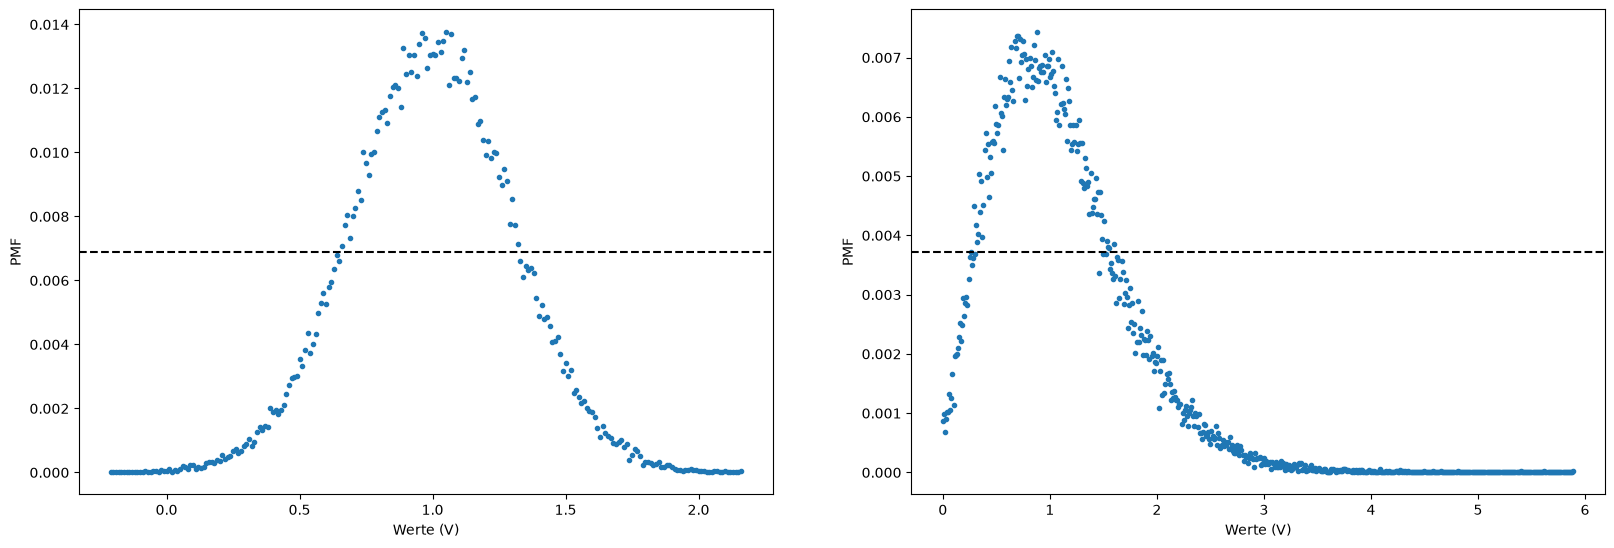

In [56]:
fig = plt.figure(figsize=(50*cm, 16*cm))

ax = fig.add_subplot(1, 2, 1)
x, px = PMF(V1, resolution)

fwhm = FWHM2(x, px)
sigma = np.sqrt(np.var(V1))

ax.plot(x, px, '.')
ax.axhline(np.max(px) / 2, color='k', linestyle='--')

ax.set_xlabel('Werte (V)')
ax.set_ylabel('PMF')

print('Erster Datensatz:')
print('FWHM: {:f}'.format(fwhm))
print('sigma: {:f} -> FWHM = {:f}'.format(sigma, 2*np.sqrt(2*np.log(2))*sigma ) )


ax = fig.add_subplot(1, 2, 2)
x, px = PMF(V2, resolution)

fwhm = FWHM2(x, px)
sigma = np.sqrt(np.var(V2))

ax.plot(x, px, '.')
ax.axhline(np.max(px)/2, color='k', linestyle='--')

ax.set_xlabel('Werte (V)')
ax.set_ylabel('PMF')

print('Zweiter Datensatz:')
print('FWHM: {:f}'.format(fwhm))
print('sigma: {:f} -> FWHM = {:f}'.format(sigma, 2*np.sqrt(2*np.log(2))*sigma ) ) 

Momente

Momente sind charakteristische Grössen für Zufallsvariablen und sind verknüpft mit Erwartungswert, Varianz, Schiefe etc. In der Vorlesung haben Sie die Formel für das n-te Moment von diskrete Zufallsvariablen gesehen:

$$m_n = \sum_{i=0}^{N}x^n_ip_i,$$

wobei der Wert $x_i$ mit Wahrscheinlichkeit $p_i$ im Datensatz vorkommt. Da $p_i = \frac{n_i}{M}$, wobei $M$ die Länge des Datenarrays und $n_i$ die Anzahl Datenpunkte $X_j$ mit Wert $x_i$ im Datenarray ist, kann man das n-te Moment auch via:

$$ m_n =\frac{1}{M}\sum_{j=0}^{M}X_j^n $$
berechnen. Dies hat den Vorteil, dass man nicht auf ein Binning angewiesen ist.



In [57]:
def moment(data, n):
    return np.sum(data**n)/len(data)

Wenn man n als ungerade Zahl nimmt schaut man es asymetrisch an als n = 3 ist also ein Mass für die Schiefe der Verteilung.

Ex09

Gausche Normalverteilung
$$ f(x) = {1 \over \sqrt{2\pi\sigma^2}} e^{-{1 \over 2}{(x-\mu)^2 \over \sigma^2}}$$

In [58]:
def normal_pmf(x, mu, sigma, binsize):
    # Wir approximieren die PMF der Gausschen Normalverteilung. Warum dies lediglich eine 
    # Approximation ist, ist im Zusatz Notebook Histogramme beschrieben.
    return 1/np.sqrt(2*np.pi*sigma**2)*np.exp(-1/2*((x-mu)**2/(sigma**2)))*binsize
#binsize wird hier nur als Streckungsfakt gabraucht sodass man es über ein Balkendiagramm legen kann

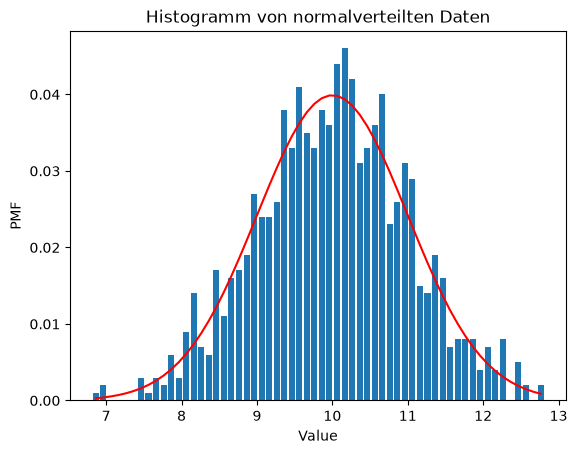

In [35]:
mu = 10
sigma = 1
# Wir ziehen Samples aus einer Gaussschen Normalverteilung mit Mittelwert mu und Standardabweichung sigma. 
normal_data = np.random.normal(mu, sigma, 1000)

binsize = 0.1
x, px = PMF(normal_data, binsize)
plt.figure()
plt.bar(x, px, width=0.08)
plt.xlabel('Value')
plt.ylabel('PMF')
plt.title('Histogramm von normalverteilten Daten')

# Überlagern des Histogramms mit der erwarteten PMF der gezogenen Daten.
plt.plot(x,normal_pmf(x,mu,sigma,binsize),'r')

Zentraler Grenzwersatz besagt das der Durchschnitt vieler verschiedener verteilungen ist annäherungsweise normalverteil

Text(0.5, 1.0, 'Umlaufzeiten der kleinen Objekte im Sonnensystem')

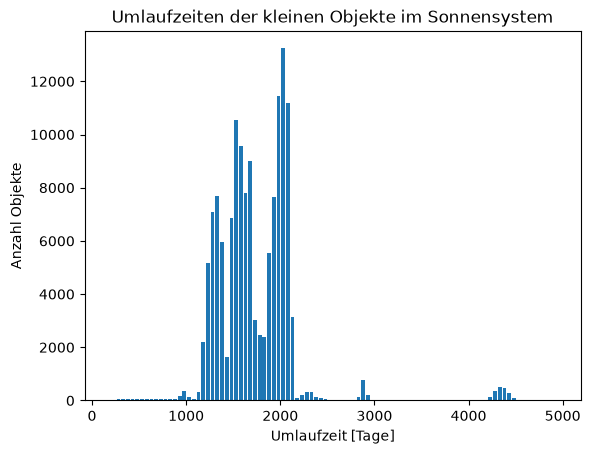

In [59]:
data = np.loadtxt('Ex09/NASA_small_body_data_period.txt', skiprows=1)


resolution = 50
x, px = PMF(data, resolution)
# Um die Anzahl an Objekten pro Bin zu erhalten, müssen wir die PMF mit der Gesamtanzahl der Objekte multiplizieren.
#da es sonst nur die Wahscheinlichkeit ist kann man so auf den gerundeten Absolutwert kommen
px = px*np.size(data)

# Plotten
plt.figure()
plt.bar(x, px, width=0.8*resolution)
plt.xlabel('Umlaufzeit [Tage]')
plt.ylabel('Anzahl Objekte')
plt.title('Umlaufzeiten der kleinen Objekte im Sonnensystem')

Hier ist es nicht normalverteilt aber wenn man viele verschiedenen mean von dem nimmt wird es normalverteilt


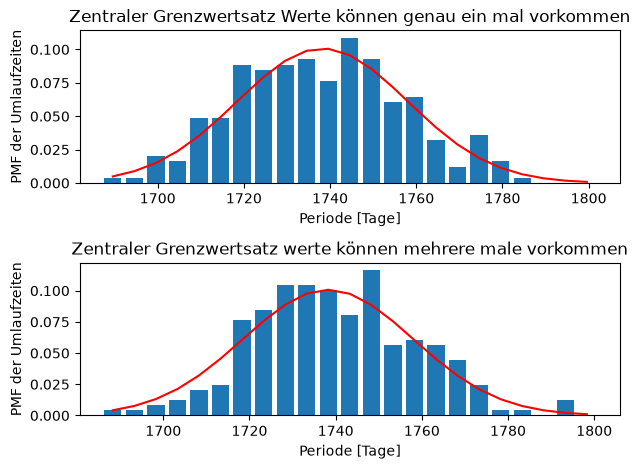

In [60]:
sample_size = 500

number_of_samples = 250

sample_means = np.zeros(number_of_samples)
sample_means2 = np.zeros(number_of_samples)

for i in range(number_of_samples):
    # Ziehe die richtige Anzahl an zufälligen Datenpunkten aus den Ursprungsdaten und 
    # berechne den Mittelwert dieser Samples.
    sample = np.random.choice(data, size=sample_size, replace=False) #false ist weil mna dann jedes obijekt nur einmal nehmen kann wenn es true wäre würde es manche obijekte zwei mal nehmen können
    sample_means[i] = np.mean(sample)
for i in range(number_of_samples):
    sample = np.random.choice(data, size=sample_size, replace =True)
    sample_means2[i] = np.mean(sample)


resolution = 5
x, px = PMF(sample_means, resolution)

# Plotten
fig = plt.figure()

ax = fig.add_subplot(2,1,1)



ax.bar(x, px, width=0.8*resolution)
ax.set_xlabel('Periode [Tage]')
ax.set_ylabel('PMF der Umlaufzeiten')
ax.set_title('Zentraler Grenzwertsatz Werte können genau ein mal vorkommen')

meanPeriod = np.mean(data)
stdPeriod = np.std(data)/np.sqrt(sample_size)
ax.plot(x,normal_pmf(x,meanPeriod,stdPeriod,resolution),'r')

x, px = PMF(sample_means2, resolution)

ax = fig.add_subplot(2,1,2)


ax.bar(x, px, width=0.8*resolution)
ax.set_xlabel('Periode [Tage]')
ax.set_ylabel('PMF der Umlaufzeiten')
ax.set_title('Zentraler Grenzwertsatz werte können mehrere male vorkommen')

meanPeriod = np.mean(data)
stdPeriod = np.std(data)/np.sqrt(sample_size)
ax.plot(x,normal_pmf(x,meanPeriod,stdPeriod,resolution),'r')
fig.tight_layout()

Mit zurücklegen
$$Var(\bar{X}) = \frac{\sigma^2}{n}$$
Ohne zurücklegen
$$Var(\bar{X}) = \frac{\sigma^2}{n}  \frac{N-n}{N-1}$$
N ist die grösse der ganzen Datenmenge und n ist die grösse der Stichprobe

Text(0.5, 0.98, 'Unterschiedliche Anzahl an Werten pro Stichprobe')

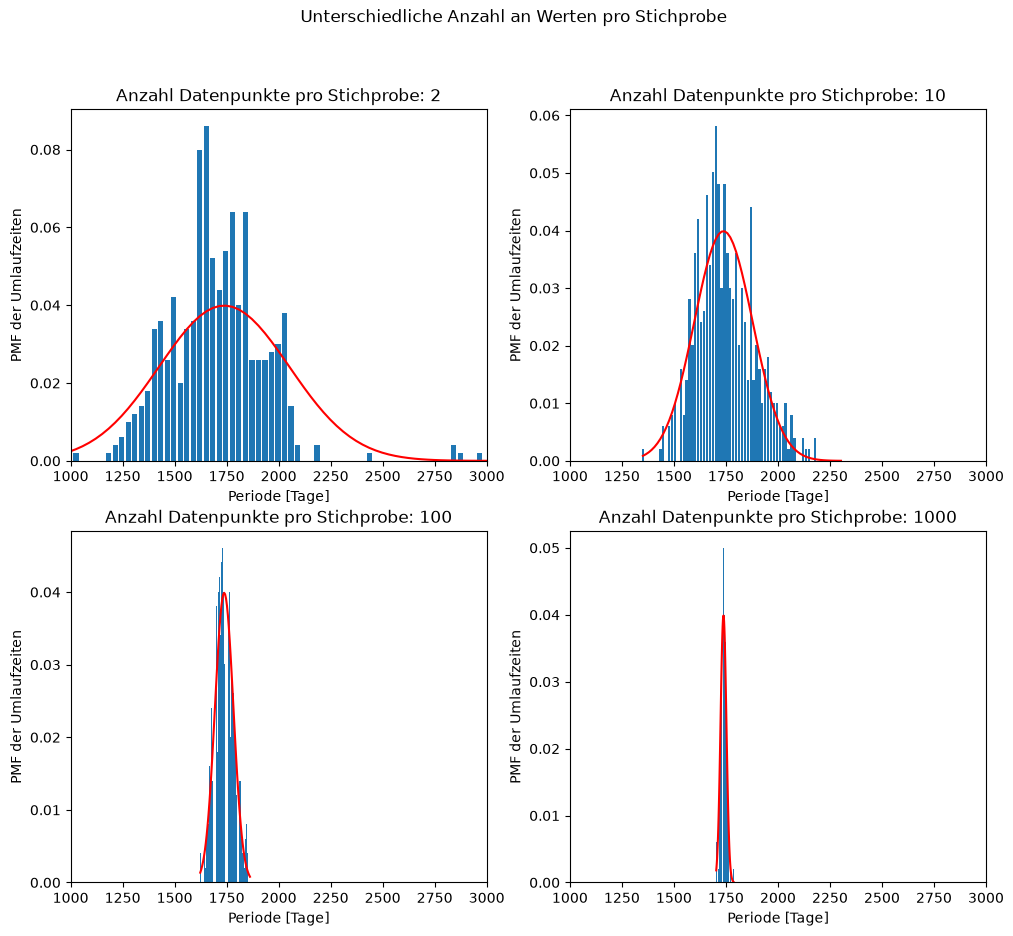

In [62]:
cm = 0.393701


n_samples_list = np.array([2, 10, 100, 1000])
number_of_samples = 500

fig = plt.figure(figsize=(30*cm, 25.5*cm))

# Wir erzeugen die Histogramme und Plots für die verschiedene Anzahl an Datenpunkten in einer for-Schleife, da
# der Code immer der gleiche ist.
for idx, sample_size in enumerate(n_samples_list):
    sample_means = np.zeros(number_of_samples)

    for i in range(number_of_samples):
        sample = np.random.choice(data, size=sample_size, replace=False)
        sample_means[i] = np.mean(sample)
        
    meanPeriod = np.mean(data) #man von der gesammt Datenmenge, weil mand ie theoretische Verteilung haben möchte
    stdPeriod = np.std(data)/np.sqrt(sample_size) #Die Wurzel der Varianz wie man oben sieht, folgt es dirket
    # Histogramm erzeugen
    resolution = stdPeriod/10 #sodass man auhc etwas erkennen kann
    x, px = PMF(sample_means, resolution)
    
    # Plotten
    ax = fig.add_subplot(2, 2, idx+1)
    ax.bar(x, px, width=0.8*resolution)
    ax.plot(x,normal_pmf(x,meanPeriod,stdPeriod,resolution),'r')
    ax.set_xlabel('Periode [Tage]')
    ax.set_ylabel('PMF der Umlaufzeiten')
    ax.set_title('Anzahl Datenpunkte pro Stichprobe: {:.0f}'.format(sample_size))
    ax.set_xlim([1000,3000])
fig.suptitle("Unterschiedliche Anzahl an Werten pro Stichprobe")

Man kann die Anzahl der samples ändern umso mehr umso genauer

also so viele samples wie man aufeinanderlegt

Text(0.5, 0.98, 'Unterschiedliche Anzahl an Stichproben')

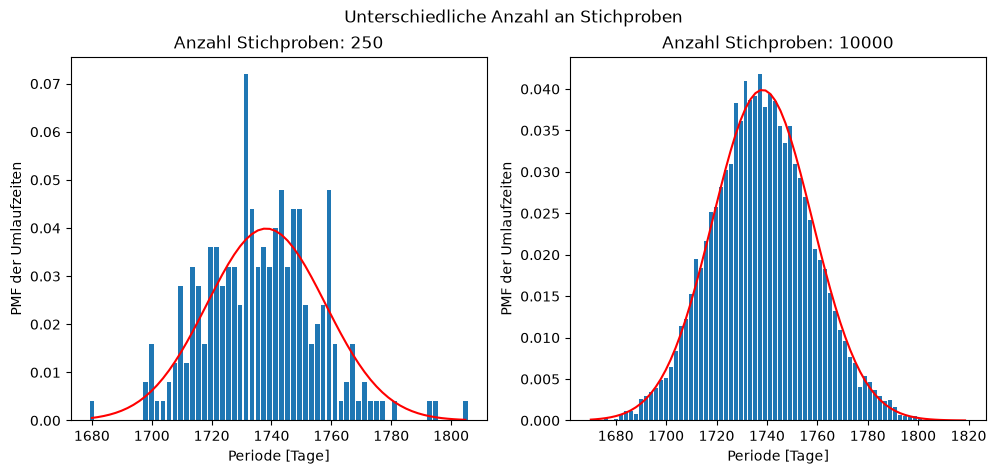

In [63]:
#Nun ändern wir die Anzahl samples, behalten jedoch die Samplegrösse von 500 Datenpunkten pro Sample

sample_size = 500
number_of_samples_list = np.array([250, 10000])

fig2 = plt.figure(figsize=(30*cm, 12*cm))

# Wir erzeugen die Histogramme und Plots für die verschiedene Anzahl an Datenpunkten in einer for-Schleife, da
# der Code immer der gleiche ist.
for idx, number_of_samples in enumerate(number_of_samples_list):
    sample_means = np.zeros(number_of_samples)

    for i in range(number_of_samples):
        sample = np.random.choice(data, size=sample_size, replace=False)
        sample_means[i] = np.mean(sample)
        
    meanPeriod = np.mean(data)
    stdPeriod = np.std(data)/np.sqrt(sample_size)
    # Histogramm erzeugen
    resolution = stdPeriod/10
    x, px = PMF(sample_means, resolution)
    
    # Plotten
    ax = fig2.add_subplot(1, 2, idx+1)
    ax.bar(x, px, width=0.8*resolution)
    ax.plot(x,normal_pmf(x,meanPeriod,stdPeriod,resolution),'r')
    ax.set_xlabel('Periode [Tage]')
    ax.set_ylabel('PMF der Umlaufzeiten')
    ax.set_title('Anzahl Stichproben: {:.0f}'.format(number_of_samples))
fig2.suptitle("Unterschiedliche Anzahl an Stichproben")

In [52]:
def draw_samples(data, sample_size, number_of_samples):
    start_points = np.random.randint(0, data.size-sample_size, size=(1,number_of_samples))
    drawn_indices = np.squeeze(np.linspace(start_points, start_points + sample_size-1 ,sample_size))
    sample_data = data[drawn_indices.astype(int)]
    
    return sample_data

Eine Funktion die alles in einmal macht die daten sind einfach nicht mehr mit random.choice ausgewählt sonder mit einem random anfangsstart und dann halt der Reihe nach.
In diesem fall sind die werten des ersten intervalls nicht im ersten subvector gespeichter sonder in der ersten Spalte als wie eine transponierte matrix

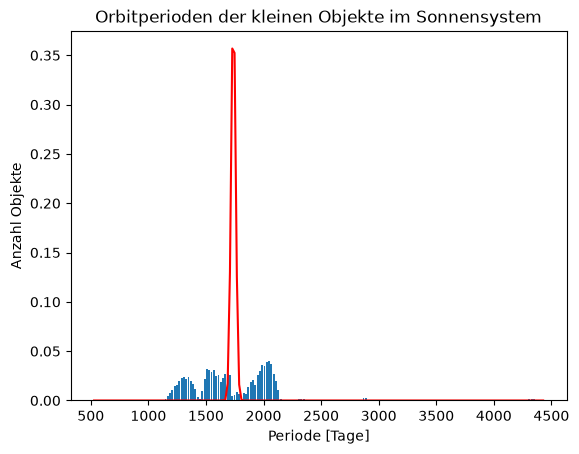

In [53]:
resolution = 20
samples = draw_samples(data, sample_size, number_of_samples)
sample_means = np.mean(samples, axis=0)

x, px = PMF(sample_means, resolution)
# Plotten
plt.figure()
plt.bar(x, px, width=0.8*resolution)
plt.xlabel('Periode [Tage]')
plt.ylabel('Anzahl Objekte')
plt.title('Orbitperioden der kleinen Objekte im Sonnensystem')

meanPeriod = np.mean(data)
stdPeriod = np.std(data)/np.sqrt(sample_size)
plt.plot(x,normal_pmf(x,meanPeriod,stdPeriod,resolution),'r')

Da zwar die Anfangs indices zufällig gewählt werden aber nachher die daraufolgenden daten genommen werden erhält keine normalverteilung die eine gausscheverteilung ähnelt da die stichproben dann nciht mehr unabhängig sind

Ex10

Man möchte daten annähern mit einer funktion
$$y(x) = f(x, \vec{a}) = a_0 + a_1 x + a_2 x^2 + \dots = \sum_{n=0}^{m} a_n x^n \qquad \mathrm{mit}\quad \vec{a} = (a_0, \dots, a_m)$$

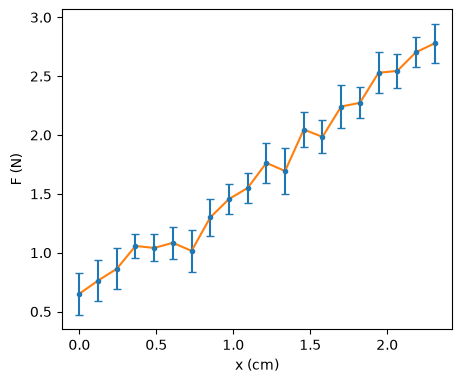

In [64]:
# Daten Laden
data = np.loadtxt('Ex10/lin_data.txt')
x_val = data[:, 0]
y_val = data[:, 1]
sigma_y = data[:, 2]

# Plot erstellen
cm = 1 / 2.54
fig = plt.figure(figsize=(12 * cm, 10 * cm))
ax = fig.add_subplot(1, 1, 1)
ax.errorbar(x_val, y_val, sigma_y , capsize=3, linestyle='None', marker='.')
ax.plot(x_val, y_val, label='Daten')

ax.set_xlabel('x (cm)')
ax.set_ylabel('F (N)')

fig.tight_layout()

bei diesen daten sieht das man eine lineare abhängigkeit hat als soltle man so etwas 
$$f(x,a_0,a_1) = a_0 + xa_1$$
Die allgeine Formel ist die man minimieren möchte ist

$$S = \sum_{n=1}^{N} \frac{(y_i - f(x_i, \vec{a}))^2}{\sigma_i^2}$$

wie man es in Analysis 1 gesehen hat

Beispiel für ein 3d Grafik

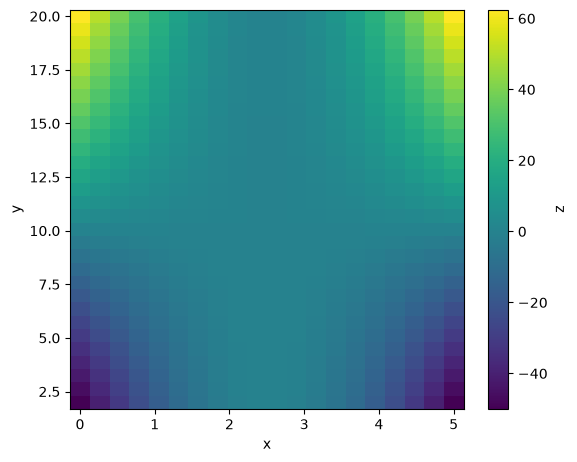

In [65]:
# Erzeuge einige Daten zum Plotten
x_example = np.linspace(0, 5, 20)
y_example = np.linspace(2, 20, 30)
z_example = np.zeros(shape=(len(y_example), len(x_example)))

for i, x in enumerate(x_example):
    for j, y in enumerate(y_example):
        z_example[j][i] = (x - 2.5)**2 * (y - 10)

    
# 2D-Plot generieren
cm = 1 / 2.54

fig = plt.figure(figsize=(15 * cm, 12 * cm))
ax = fig.add_subplot(1, 1, 1)

# Beachten Sie, dass das Z-Array transponiert werden muss (.T), weil die
# pcolormesh erwartet, dass die erste Achse (äusseres Array) den vertikalen
# Pixeln (y-Achse) enspricht und die zweite Achse (inneres Array) den horizontalen.
im = ax.pcolormesh(x_example, y_example, z_example, shading='nearest')

# Colorbar für die Farbskala, mit Achsenbeschriftung
fig.colorbar(im, label='z')

ax.set_xlabel('x')
ax.set_ylabel('y')

fig.tight_layout()

oder

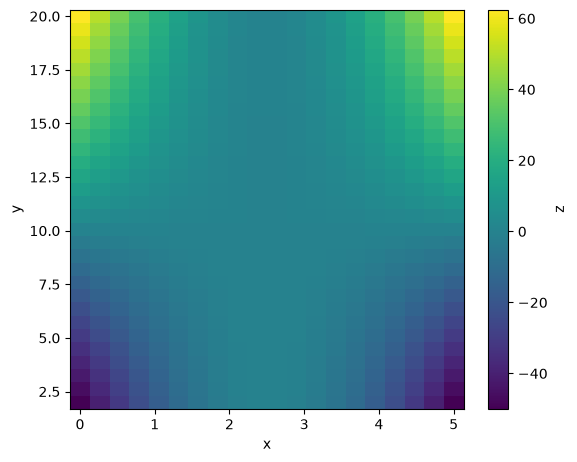

In [66]:
# Erzeuge einige Daten zum Plotten
x_example = np.linspace(0, 5, 20)
y_example = np.linspace(2, 20, 30)
z_example = np.zeros(shape=(len(x_example), len(y_example)))

for i, x in enumerate(x_example):
    for j, y in enumerate(y_example):
        z_example[i][j] = (x - 2.5)**2 * (y - 10)

    
# 2D-Plot generieren
cm = 1 / 2.54

fig = plt.figure(figsize=(15 * cm, 12 * cm))
ax = fig.add_subplot(1, 1, 1)

# Beachten Sie, dass das Z-Array transponiert werden muss (.T), weil die
# pcolormesh erwartet, dass die erste Achse (äusseres Array) den vertikalen
# Pixeln (y-Achse) enspricht und die zweite Achse (inneres Array) den horizontalen.
im = ax.pcolormesh(x_example, y_example, z_example.T, shading='nearest')

# Colorbar für die Farbskala, mit Achsenbeschriftung
fig.colorbar(im, label='z')

ax.set_xlabel('x')
ax.set_ylabel('y')

fig.tight_layout()

die erste variante mach mehr sinn da man direkt die daten an der richtigem ort speicher und nicht noch transponieren muss

Man nimmt die Funktion S von vorhin und plottet sie dann sieht man wo die funktion minial ist

In [67]:
# Wertebereiche für a0 und a1 definieren
a0_range = np.linspace(-0.5, 1.5, 50)
a1_range = np.linspace(0, 2, 60)

# Array für die berechneten S initialisieren
S = np.zeros(shape=(50, 60))

# S für alle Kombinationen berechnen
for i, a0 in enumerate(a0_range):
    for j, a1 in enumerate(a1_range):
        S[i, j] = np.sum((y_val - (a0 + a1 * x_val))**2 / sigma_y**2)

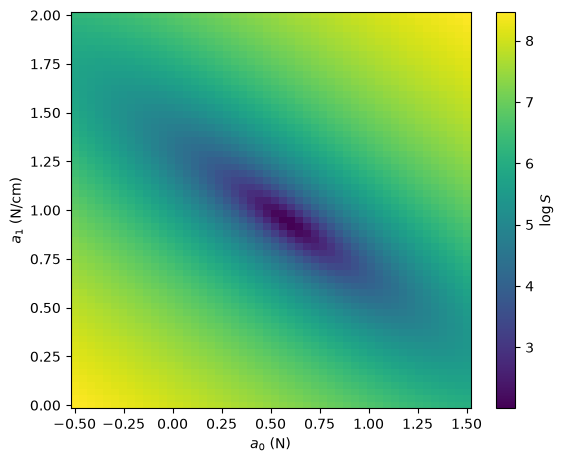

In [68]:
cm = 1 / 2.54
fig = plt.figure(figsize=(15 * cm, 12 * cm))
ax = fig.add_subplot(1, 1, 1)

im = ax.pcolormesh(a0_range, a1_range, np.log(S).T, shading='nearest')
fig.colorbar(im, label=r'$\log S$')

ax.set_xlabel('$a_0$ (N)')
ax.set_ylabel('$a_1$ (N/cm)')

fig.tight_layout()

Man kann das auch mathematisch berechnen man erhält die matrixen


$$
N = \begin{pmatrix}\sum_i w_i & \sum_i w_i x_i \\ \sum_i w_i x_i & \sum_i w_i x_i^2 \end{pmatrix}
$$
und den Vektor
$$
\vec{Y} = \begin{pmatrix} \sum_i w_i y_i \\ \sum_i w_i x_i y_i \end{pmatrix},
$$


In [69]:


N = np.zeros(shape=(2, 2))
Y = np.zeros(shape=(2,))  # '(2,)' ist ein Tupel mit nur einem Eintrag. '(2)' ohne Komma gibt ein Integer.

# N und Y berechnen. Da wir hier ein Polynom ersten Grades fitten (m = 1), können wir einfach
# jedes Element einzeln hinschreiben.
# Allgemeinere Lösung siehe unten.
N[0, 0] = np.sum(1 / sigma_y**2)
N[0, 1] = np.sum(x_val / sigma_y**2)
N[1, 0] = np.sum(x_val / sigma_y**2)
N[1, 1] = np.sum(x_val**2 / sigma_y**2)

Y[0] = np.sum(y_val / sigma_y**2)
Y[1] = np.sum(y_val * x_val / sigma_y**2)

# Lösungsvektor
a0, a1 = np.linalg.inv(N) @ Y #gg 

# Kovarianzmatrix
# Die Unsicherheiten (Standardabweichung) der gefitteten Parameter bekommt man
# aus der Wurzel der Diagonaleinträge.
C = np.linalg.inv(N)
sig_a0 = np.sqrt(C[0, 0])
sig_a1 = np.sqrt(C[1, 1])

# Resultate ausgeben (Unicode string für das "Plusminus"-Zeichen)
print(u'a_0 = ({:.3f} \u00b1 {:.3f}) N\na_1 = ({:.3f} \u00b1 {:.3f}) N/cm'.format(a0, sig_a0, a1, sig_a1))

a_0 = (0.588 ± 0.063) N
a_1 = (0.939 ± 0.047) N/cm


In der oberen rechnung ist noch ein bisschen Linearealgebra dabei

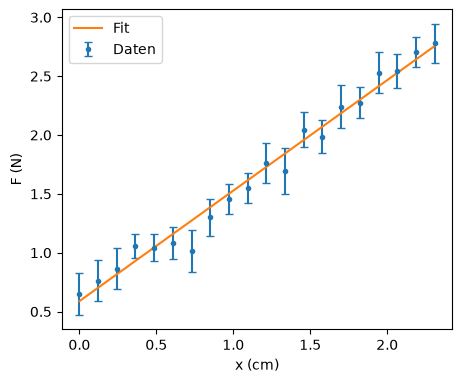

In [70]:
cm = 1 / 2.54
fig = plt.figure(figsize=(12 * cm, 10 * cm))
ax = fig.add_subplot(1, 1, 1)

ax.errorbar(x_val, y_val, sigma_y, capsize=3, linestyle='None', marker='.', label='Daten')
ax.plot(x_val, a0 + a1 * x_val, label='Fit')
ax.legend()

ax.set_xlabel('x (cm)')
ax.set_ylabel('F (N)')

fig.tight_layout()

Eine funktion die jede datemenge bis zu einem gewissen grad fittet

In [71]:
def linear_fit(x, y, sigma, m):
    '''Perform a linear fit with a polynomial of order m. Returns an array of length m containing
    the optimized coefficients of the fit.'''
    # Gewichte
    w = 1 / sigma**2
    
    # N und Y berechnen. Ein Polynom von Grad m hat m+1 Koeffizienten.
    N = np.zeros(shape=(m+1, m+1))
    Y = np.zeros(shape=(m+1, ))
    
    # Durch Betrachten der Normalmatrix kann man erkennen, dass der Exponent
    # von x in jedem Eintrag der Summe Indizes diese Eintrags entspricht.
    # Ähnlich ist es beim Vektor Y.
    for i in range(m + 1):
        Y[i] = np.sum(w * y * x**i)
        for j in range(m + 1):
            
            N[i, j] = np.sum(w * x**(i+j))
            
    # Kovarianzmatrix
    C = np.linalg.inv(N)
    # Lösungsvektor berechnen und ausgeben
    a_vec = C @ Y
    return a_vec, C

Beispiel an einer Spannung man berechnet für jeden Punkt in der Messung der Wert der annäherung

In [72]:
# Neuen Datensatz laden
data = np.loadtxt('Ex10/poly_data.txt')
u_val = data[:, 0]
i_val = data[:, 1]
sigma_i = data[:, 2]


m = 3
# Lösungsvektor mit der Funktion von oben berechnen.
a_vec_m3, C_m3 = linear_fit(u_val, i_val, sigma_i, m)

# Die erwarteten y-Werte aus dem Fit sind
#    f(x_i, a_opt) = a0 + a1 * x + a2 * x**2 + ... + a_m * x**m.
# Für jeden Datenpunkt x_i müssen wir also die Summe über n von a_n x_i**n berechnen
i_fit_m3 = np.zeros(len(u_val))
for index, x_i in enumerate(u_val):
    sum_i = 0
    for n, a_n in enumerate(a_vec_m3):
        sum_i += a_n * x_i**n
        
    i_fit_m3[index] = sum_i


# Das gleiche für m = 4 und m = 5.
m = 4
a_vec_m4, C_m4 = linear_fit(u_val, i_val, sigma_i, m)

i_fit_m4 = np.zeros(len(u_val))
for index, x_i in enumerate(u_val):
    sum_i = 0
    for n, a_n in enumerate(a_vec_m4):
        sum_i += a_n * x_i**n
        
    i_fit_m4[index] = sum_i
    
m = 5
a_vec_m5, C_m5 = linear_fit(u_val, i_val, sigma_i, m)

i_fit_m5 = np.zeros(len(u_val))
for index, x_i in enumerate(u_val):
    sum_i = 0
    for n, a_n in enumerate(a_vec_m5):
        sum_i += a_n * x_i**n
        
    i_fit_m5[index] = sum_i

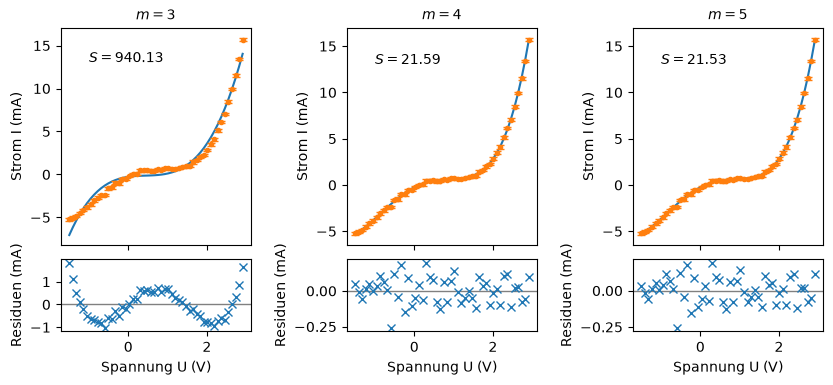

In [73]:
# Um mehr Kontrolle über die Anordnung von Plots auf einem Gitter zu haben, verwenden wir
# matplotlib.gridspec
import matplotlib.gridspec as gs

# Plotten
cm = 1 / 2.54
fig = plt.figure(figsize=(25 * cm, 10 * cm))

# Definere das Gitter-Layout mit unterschiedlicher Höhe für die zwei Zeilen.
gs0 = gs.GridSpec(nrows=2, ncols=3, height_ratios=[3, 1], hspace=.1, figure=fig)
#gspace abstand zwischen den beiden Grafiken

###### m = 3
# Plots hinzufügen geht dann so:
ax1 = fig.add_subplot(gs0[0, 0])

# Der Rest wie gewohnt
ax1.plot(u_val, i_fit_m3)
ax1.errorbar(u_val, i_val, sigma_i, capsize=3, linestyle='None', marker='.')

ax1.set_ylabel('Strom I (mA)')
ax1.set_xticklabels([])  # Entferne Labels, weil die Achse gleich wie im Plot unten ist
ax1.set_title('$m = 3$', size=10)

ax1.text(-1, 13, '$S = ${:.2f}'.format(np.sum((i_val - i_fit_m3)**2 / sigma_i**2)))

# Residuen
ax2 = fig.add_subplot(gs0[1, 0])
ax2.axhline(0, color='0.5', linewidth=1)
ax2.plot(u_val, i_val - i_fit_m3, 'x')

ax2.set_xlabel('Spannung U (V)')
ax2.set_ylabel('Residuen (mA)')


###### m = 4
ax3 = fig.add_subplot(gs0[0, 1])

ax3.plot(u_val, i_fit_m4)
ax3.errorbar(u_val, i_val, sigma_i, capsize=3, linestyle='None', marker='.')

ax3.set_ylabel('Strom I (mA)')
ax3.set_xticklabels([])
ax3.set_title('$m = 4$', size=10)

ax3.text(-1, 13, '$S = ${:.2f}'.format(np.sum((i_val - i_fit_m4)**2 / sigma_i**2)))
         
# Residuen
ax4 = fig.add_subplot(gs0[1, 1])
ax4.axhline(0, color='0.5', linewidth=1)
ax4.plot(u_val, i_val - i_fit_m4, 'x')

ax4.set_xlabel('Spannung U (V)')
ax4.set_ylabel('Residuen (mA)')


###### m = 5
ax5 = fig.add_subplot(gs0[0, 2])

ax5.plot(u_val, i_fit_m5)
ax5.errorbar(u_val, i_val, sigma_i, capsize=3, linestyle='None', marker='.')

ax5.set_ylabel('Strom I (mA)')
ax5.set_xticklabels([])
ax5.set_title('$m = 5$', size=10)

ax5.text(-1, 13, '$S = ${:.2f}'.format(np.sum((i_val - i_fit_m5)**2 / sigma_i**2)))
         
# Residuen
ax6 = fig.add_subplot(gs0[1, 2])
ax6.axhline(0, color='0.5', linewidth=1)
ax6.plot(u_val, i_val - i_fit_m5, 'x')

ax6.set_xlabel('Spannung U (V)')
ax6.set_ylabel('Residuen (mA)')


##
fig.subplots_adjust(wspace=.5)  # Layout anpassen, damit die Achsenbeschriftungen nicht überlappen

Es macht keinen Sinn m sehr gross zu machen den die Messdaten haben immer eine weniger unsicherheit deshalb würde man die daten zwar perfekt fittet dafür ist es in der realität nicht mehr mehr als so richtig. was für ein komischer Satz aber man soltle es vertsehen

Ex11


Wiedeholung der vorderen Woche

Bei t = 0s ist V = 5.79 V, also A = 5.79 V
Dabei ist  V(0)/e = 2.13 V und schlussendlich tau = 0.2 s 


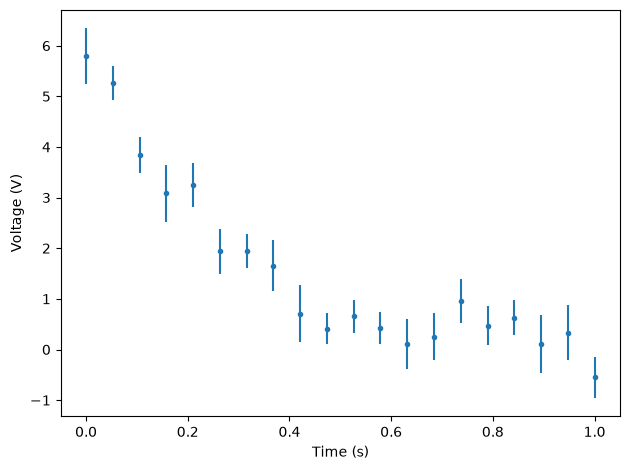

In [74]:
data = np.loadtxt('Ex11/decay.txt', skiprows=1)
t = data[0, :]
V = data[1, :]
sigma = data[2, :]


fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.errorbar(t, V, yerr=sigma, marker='.', linestyle='None')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (V)')

fig.tight_layout()

print('Bei t = 0s ist V = {:0.2f} V, also A = {:0.2f} V'.format(V[0], V[0]))
print('Dabei ist  V(0)/e = {:0.2f} V und schlussendlich tau = 0.2 s '.format(V[0]/np.exp(1)))

In [75]:
def exp(t, a):
    return a[0] * np.exp(-t / a[1]) #a[0] = A, a[1] = tau

def Sres(x, y, sigma, f, a):
    return np.sum((y - f(x,a))**2 / sigma**2)

In [76]:
# Wir definieren die Testwerte rund um unsere Schätzung der vorherigen Aufgabe. 
A_range = np.linspace(5, 7, 50)
tau_range = np.linspace(0.1, 0.4, 51)

# Array um die Werte zu speichern
S = np.zeros((len(A_range), len(tau_range)))

# Iteration durch die beiden Arrays mit den Testwerten
for i, A in enumerate(A_range):
    for j, tau in enumerate(tau_range):
        S[i, j] = Sres(t, V, sigma, exp, [A, tau])

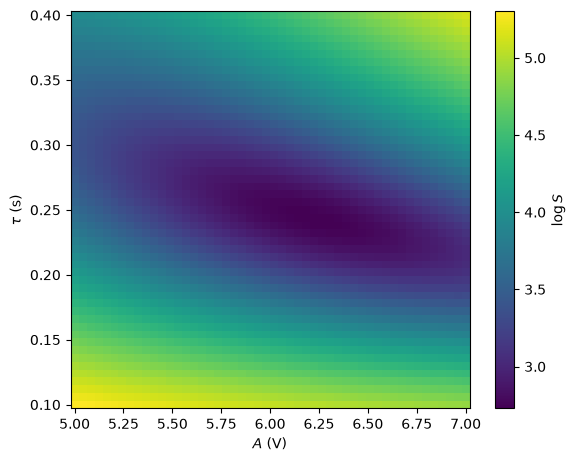

In [77]:
cm = 1 / 2.54
fig = plt.figure(figsize=(15 * cm, 12 * cm))
ax = fig.add_subplot(1, 1, 1)

im = ax.pcolormesh(A_range, tau_range, np.log(S).T, shading='nearest')
fig.colorbar(im, label=r'$\log S$')

# Wir zeichnen die geschätzten Werte mit Linien ein.


ax.set_xlabel('$A$ (V)')
ax.set_ylabel(r'$\tau$ (s)')

fig.tight_layout()

Das Gradient verfahren dafür benötigen wir die erste und zweite ableitung nach jeder variable

Die erste Funktion gibt einem die hessian matrix die zweite einfach die abelting nahc jedem parameter

In [78]:
def dS2 (x, y, sigma, f, a, delta):
    # Leere Matrix um die Komponenten zu speichern
    delta_S2 = np.zeros((len(a), len(a)))
    
    # Da wir über alle Kombinationen der a_i's ableiten müssen, iterieren wir in zwei verschachtelten Schlaufen über die
    # Einträge von a. 
    for i in range(len(a)):
        for j in range(len(a)):
            # Wir definieren neue Delta-Vektoren, die nur einen Eintrag in der Entsprechenden Dimension haben z.B. (Delta, 0)
            delta_i = np.zeros(len(a))
            delta_j = np.zeros(len(a))
            delta_i[i] = delta
            delta_j[j] = delta
            
            # Und wir berechnen die Matrixelemente so wie in der Aufgabenstellung gegeben.
            delta_S2[i,j] = (  Sres(x, y, sigma, f, a + delta_i + delta_j)
                             - Sres(x, y, sigma, f, a - delta_i + delta_j)
                             - Sres(x, y, sigma, f, a + delta_i - delta_j)
                             + Sres(x, y, sigma, f, a - delta_i - delta_j)) / (4 * delta * delta)
    return delta_S2

In [79]:
def dS(x, y, sigma, f, a, delta):
    delta_S = np.zeros(len(a))
    
    for i in range(len(a)):
        delta_i = np.zeros(len(a))
        delta_i[i] = delta
        delta_S[i] = (Sres(x, y, sigma, f, a + delta_i) - Sres(x, y, sigma, f, a - delta_i)) / (2 * delta)
        
    return delta_S

Das Gradient verfahren keine Ahnung wie das funktioniert aber auch nicht wichtig hier ist die Funtion

In [80]:
def gradient_descent(x, y, sigma, f, a0, delta, alpha, mingrad, imax):
    # a für die erste iteration
    a_next = a0
    
    # Berechnen des Gradienten
    current_gradient = dS(x, y, sigma, f, a_next, delta)
    
    # Berechnen der Norm des Gradienten
    norm = [np.linalg.norm(current_gradient)]
    
    # Speichern der Parameter (Bonus Aufgabe)
    a = np.zeros((int(imax),2))
    a[0] = a_next
    
    # Initialisieren der Iterationsvariablen
    i = 0
    while norm[i] > mingrad and i <= imax:
        # Parameter für die nächste Iteration
        a_next = a_next - alpha * current_gradient
        
        # Gradient und Norm berechnen
        current_gradient = dS(x, y, sigma, f, a_next, delta)
        norm.append(np.linalg.norm(current_gradient))
        a[i] = a_next
        i += 1 
        
    # Die Kovarianzmatrix ergibt sich aus der invertierten zweiten Ableitung.
    cov = 2*np.linalg.inv(dS2(x, y, sigma, f, a_next, delta))
    
    # Wir entfernen die überzählingen Nullen am Ende des Arrays
    a = a[:i, :]
    return a_next, cov, norm, i, a

hier ein Beipspiel

In [81]:
# Anfangsparameter
a0 = [5.79, 0.2]

# Fitparameter
delta = 1e-4
alpha = 1e-5
mingrad = 1e-3
imax = 1e5

# Fitten der Funktion
a_opt, cov, norm, n_iter, a = gradient_descent(t, V, sigma, exp, a0, delta, alpha, mingrad, imax)

# Berechnen der Standardabweichung aus der Kovarianzmatrix
std = np.sqrt(np.diag(cov))

print(u'Die optimalen parameter sind A = {:0.2f}V \u00b1 {:0.2f}V und tau = {:0.3f}s \u00b1 {:0.3f}s'
      .format(a_opt[0], std[0], a_opt[1], std[1]))
print('Es hat {:n} Iterationen benötigt.'.format(n_iter))

Die optimalen parameter sind A = 6.22V ± 0.33V und tau = 0.244s ± 0.019s
Es hat 49362 Iterationen benötigt.


Noch einmal dargestellt und wie sich der fehler verkleinert

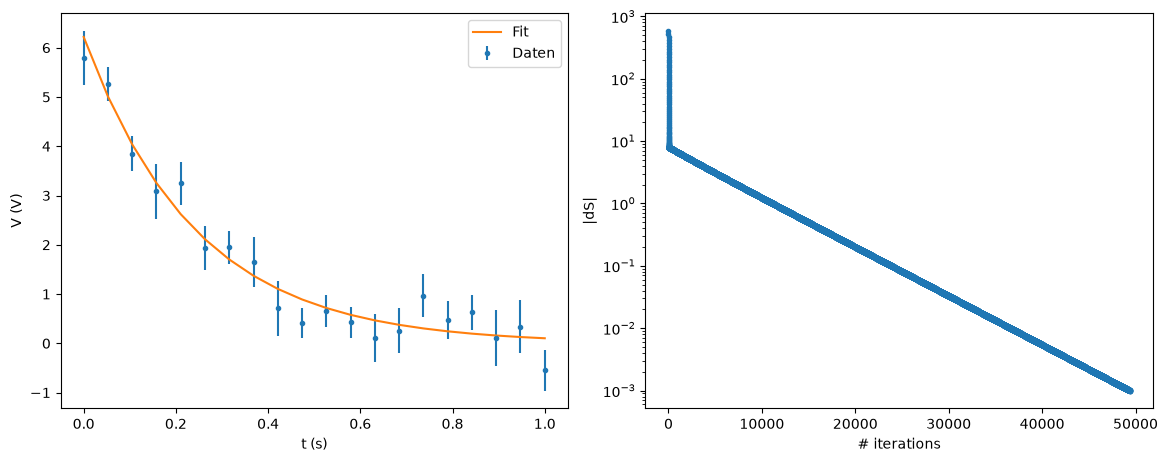

In [82]:
cm = 1 / 2.54
fig = plt.figure(figsize=(30 * cm, 12 * cm))

ax = fig.add_subplot(1, 2, 1)
ax.errorbar(t, V, yerr=sigma, marker='.', linestyle='none', label='Daten')

# Wir plotten die Fitfunktion zusammen mit dem optimalen Parameter für a
ax.plot(t, exp(t, a_opt), label='Fit')
ax.set_xlabel('t (s)')
ax.set_ylabel('V (V)')
ax.legend()

ax = fig.add_subplot(1, 2, 2)
ax.semilogy(norm,'.')
ax.set_xlabel('# iterations')
ax.set_ylabel('|dS|')

fig.tight_layout()

Hier der We der die Parameter mache bei der optimierung

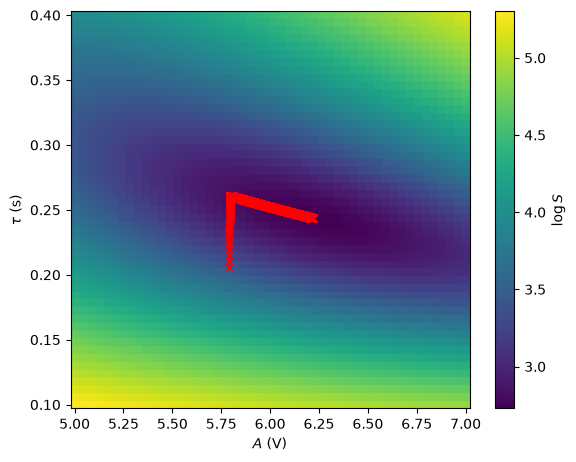

In [83]:
cm = 1 / 2.54
fig = plt.figure(figsize=(15 * cm, 12 * cm))

ax = fig.add_subplot(1, 1, 1)
im = ax.pcolormesh(A_range, tau_range, np.log(S).T, shading='nearest')
fig.colorbar(im, label=r'$\log S$')

# Entsprechend unserer Definition entspricht der erste Eintrag der Amplitude und der zweite der Zerfallszeit
ax.plot(a[:, 0], a[:, 1], marker='x', color='r')

ax.set_xlabel('$A$ (V)')
ax.set_ylabel(r'$\tau$ (s)')
fig.tight_layout()

Das Verfahren lässt sich beschleunigen, indem man die Schrittgrösse $\alpha$ proportional zur Steigung von $dS$, also der zweiten Ableitung, skaliert. Die entsprechende Formel für die Parameter ist wie folgt:
$$
a_i = a_{i,0} - \alpha\left(\frac{\partial^2 S}{\partial a_i \partial a_i}\right)^{-1} \frac{\partial S}{\partial a_i}
$$

Die Funktion ist:

In [84]:
def gradient_descent_adaptive(x, y, sigma, f, a_next, delta, alpha, mingrad, imax):
    # Analog zur bisherigen Funktion
    current_gradient = dS(x, y, sigma, f, a_next, delta)
    norm = [np.linalg.norm(current_gradient)]
    
    # Berechnen der Diagonalelemente der zweiten Ableitung
    h_diag = np.diag(dS2(x, y, sigma, f, a_next, delta))
    a = np.zeros((imax, 2))
    a[0] = a_next
    i = 0
    while norm[i] > mingrad and i <= imax:
        # Skalierung der nächsten Parameter mit der zweiten Ableitung
        a_next = a_next - alpha/(h_diag)*current_gradient
        current_gradient = dS(x, y, sigma, f, a_next, delta)
        norm.append(np.linalg.norm(current_gradient))
        h_diag = np.diag(dS2(x, y, sigma, f, a_next, delta)) 
        i += 1 
        a[i] = a_next
    
    a = a[:i, :]
    cov = 2 * np.linalg.inv(dS2(x, y, sigma, f, a_next, delta))
    return a_next, cov, norm, i, a

Die gleichen Grafiken wie vorher einfach mit den adaption

In [15]:
a0 = [6, 0.2]
delta = 1e-4
alpha = 1e0
mingrad = 1e-3
imax = 50000

a_opt, cov, norm_adaptive, imax, a= gradient_descent_adaptive(t, V, sigma, exp, a0, delta, alpha, mingrad, imax)
std = np.sqrt(np.diag(cov))

print(u'Die optimalen parameter sind A = {:0.2f}V \u00b1 {:0.2f}V und tau = {:0.3f}s \u00b1 {:0.3f}s'
      .format(a_opt[0], std[0],a_opt[1], std[1]))
print('Es hat {:n} iterationen benötigt'.format(imax))

Die optimalen parameter sind A = 6.22V ± 0.33V und tau = 0.244s ± 0.019s
Es hat 31 iterationen benötigt


bemerke viel, weniger iterationen

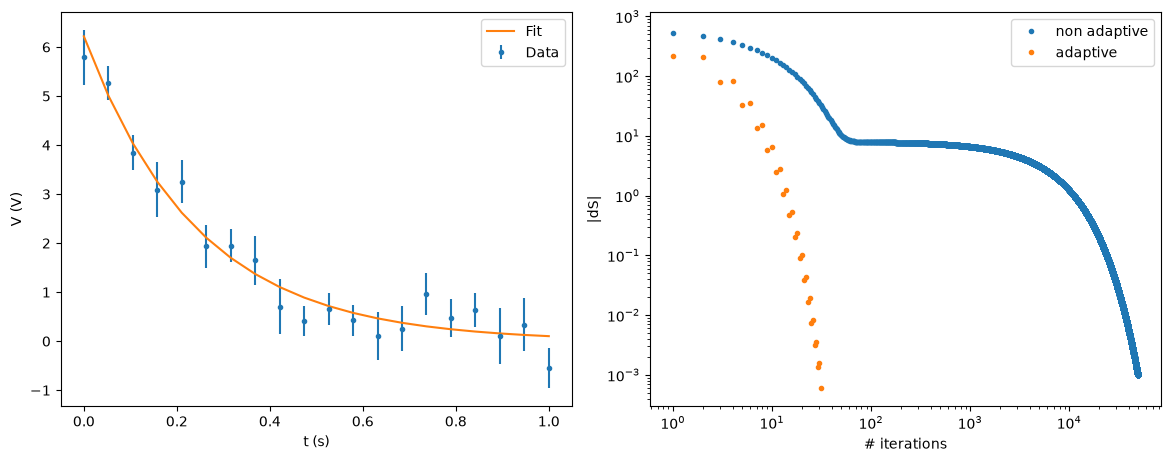

In [16]:
cm = 1 / 2.54
fig = plt.figure(figsize=(30 * cm, 12 * cm))
ax = fig.add_subplot(1, 2, 1)
ax.errorbar(t, V, yerr=sigma, marker='.', linestyle='none', label='Data')
ax.plot(t, exp(t,a_opt), label='Fit')
ax.set_xlabel('t (s)')
ax.set_ylabel('V (V)')
ax.legend()

ax = fig.add_subplot(1, 2, 2)
ax.semilogy(norm, '.', label='non adaptive')
ax.loglog(norm_adaptive, '.', label='adaptive')
ax.legend()
ax.set_xlabel('# iterations')
ax.set_ylabel('|dS|')


fig.tight_layout()

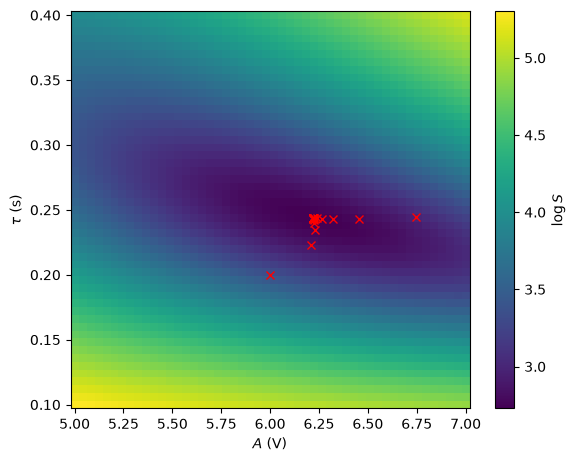

In [17]:
cm = 1 / 2.54
fig = plt.figure(figsize=(15 * cm, 12 * cm))
ax = fig.add_subplot(1, 1, 1)

im = ax.pcolormesh(A_range, tau_range, np.log(S).T, shading='nearest')
fig.colorbar(im, label=r'$\log S$')

ax.plot(a[:,0], a[:,1], 'rx')

ax.set_xlabel('$A$ (V)')
ax.set_ylabel(r'$\tau$ (s)')
fig.tight_layout()

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


Man kann es auch mit curve fit berechnen dafür funktion, die variabeln, anfangswert, wie unten in der Funktion 

falls man ein sigma für jeden Datenpunkt hat kann man sigma true machen sonst sigma false

V ist immer was die Funktion gibt und t ist die variable in der V bestimmt wird falls V von mehreren variabeln bestimmt wird muss man es als tuple schreiben

er list aus der Funktion heraus wie viele parameter er herausfinden muss

## Curve Fit (`scipy.optimize.curve_fit`)

Mit `curve_fit` kann eine Modellfunktion an Messdaten angepasst werden. Dabei werden die unbekannten **Fitparameter** so bestimmt, dass die Funktion die Messdaten möglichst gut beschreibt (Least-Squares-Fit).

### Allgemeiner Aufruf

```python
popt, pcov = curve_fit(
    modellfunktion,
    x,
    y,
    p0=...,
    sigma=...,
    absolute_sigma=True
)
```

### Parameter

- **`modellfunktion`**: Die Funktion, die an die Messdaten angepasst werden soll.
- **`x`**: Die unabhängige(n) Variable(n). Hängt die Funktion von mehreren Variablen ab, werden diese als Tupel übergeben, z. B. `(x, y)`.
- **`y`**: Die gemessenen Werte (Ausgabe der Modellfunktion).
- **`p0`**: Startwerte für die Fitparameter (optional, aber besonders bei nichtlinearen Fits empfehlenswert).
- **`sigma`**: Messunsicherheiten der einzelnen Datenpunkte (optional).
- **`absolute_sigma`**:
  - `True`: `sigma` enthält die tatsächlichen Messunsicherheiten.
  - `False`: `sigma` dient nur als relative Gewichtung der Messpunkte.

### Rückgabewerte

- **`popt`**: Optimale Fitparameter.
- **`pcov`**: Kovarianzmatrix der Fitparameter.

Die Unsicherheiten der Fitparameter erhält man mit:

```python
parameter_error = np.sqrt(np.diag(pcov))
```

### Wichtige Hinweise

- Das **erste Argument** der Modellfunktion ist immer die unabhängige Variable.
- **Alle weiteren Argumente** sind die Fitparameter, die `curve_fit` automatisch bestimmt.
- `curve_fit` erkennt anhand der Modellfunktion automatisch, wie viele Fitparameter gesucht werden müssen.

### Beispiel

```python
from scipy.optimize import curve_fit
import numpy as np

def f(x, a, b, c):
    return a * x**2 + b * x + c

popt, pcov = curve_fit(
    f,
    x,
    y,
    p0=[1, 1, 1]
)

a, b, c = popt
da, db, dc = np.sqrt(np.diag(pcov))
```

In [86]:
def exp_cf(t, A, tau):
    return A*np.exp(-t/tau)

# Startwerte
a0 = [6, 0.2]

# Fitten
a_opt_cf, conv_cf = curve_fit(exp_cf, t, V, p0=a0, sigma=sigma, absolute_sigma=True)

# Berechnen der Standardabweichung
std_cf = np.sqrt(np.diag(conv_cf))

print('Berechnen der Werte mit curve_fit:')
print(u'A = {:0.2f}V \u00b1 {:0.2f}V und tau = {:0.4f}s \u00b1 {:0.5f}s'
      .format(a_opt_cf[0], std_cf[0], a_opt_cf[1], std_cf[1]))
print('Berechnen der Werte mit der eigenen Funktion:')
print(u'A = {:0.2f}V \u00b1 {:0.2f}V und tau = {:0.3f}s \u00b1 {:0.3f}s'
      .format(a_opt[0], std[0], a_opt[1], std[1]))

Berechnen der Werte mit curve_fit:
A = 6.22V ± 0.34V und tau = 0.2436s ± 0.01980s
Berechnen der Werte mit der eigenen Funktion:
A = 6.22V ± 0.33V und tau = 0.244s ± 0.019s


Ex12

Benutzen von pandas 

einlesen

In [2]:
df = pd.read_csv('Ex12/Aufgabenblatt12/daten/periodic_table.csv')


und dann die ersten n Zeilen anzeigen

In [15]:
df.head(n = 1) #df.head() zeig alles an

,Name,Symbol,Atomic_Number,Atomic_Weight,Density,Melting_Point,Boiling_Point,Atomic_Radius,Covalent_Radius,Ionic_Radius,...,Specific_Heat,Heat_Fusion,Heat_Evaporation,Thermal_Conductivity,Pauling_Electronegativity,First_Ionisation_Energy,Oxidation_States,Electronic_Configuration,Lattice,Lattice_Constant
0,Hydrogen,H,1,1.00794,0.0708 (@ -253degC),14.01,20.28,79,32,NaN,...,14.267 (H-H),0.117 (H-H),0.904 (H-H),0.1815,2.2,1311.3,1 -1,1s¹,HEX,3.75


man kann auch nur eine Spalte auswählen

In [6]:
df['Atomic_Weight']

0       1.00794
1      4.002602
2         6.941
3       9.01218
4        10.811
         ...   
113       [289]
114           -
115           -
116           -
117           -
Name: Atomic_Weight, Length: 118, dtype: str

oder mehrere

In [7]:
df[['Symbol', 'Melting_Point', 'Boiling_Point']]

,Symbol,Melting_Point,Boiling_Point
0,H,14.01,20.28
1,He,0.95,4.216
2,Li,553.69,1118.15
3,Be,1551,3243
4,B,2573,3931
...,...,...,...
113,Uuq,-,-
114,Uup,-,-
115,Uuh,-,-
116,Uus,-,-


Um einzelne Spalten zu entfernen, können Sie die Methode `drop` wie nachfolgend angegeben nutzen. 

*Beachten Sie, dass diese nicht das Dataframe `df` verändert, sondern ein neues Dataframe zurückgibt, aus welchem die entsprechenden Spalten entfernt sind.*  

In [8]:
df_with_dropped_column = df.drop(columns = ["Symbol", "Melting_Point"])

Um einzelne Zeilen auszuwählen, nutzen wir die Methode `iloc`. Wir können einzelne Indizes, oder wie bei Numpy einen Bereich angeben. 

In [14]:
df.iloc[5:10]

,Name,Symbol,Atomic_Number,Atomic_Weight,Density,Melting_Point,Boiling_Point,Atomic_Radius,Covalent_Radius,Ionic_Radius,...,Specific_Heat,Heat_Fusion,Heat_Evaporation,Thermal_Conductivity,Pauling_Electronegativity,First_Ionisation_Energy,Oxidation_States,Electronic_Configuration,Lattice,Lattice_Constant
5,Carbon,C,6,12.011,2.25 (graphite),3820,5100,91,77,NaN,...,0.711,-,-,1.59,2.55,1085.7,4 2 -4,[He]2s²2p²,DIA,3.57
6,Nitrogen,N,7,14.00674,0.808 (@ -195.8degC),63.29,77.4,92,75,NaN,...,1.042 (N-N),-,-,0.026,3.04,1401.5,5 4 3 2 -3,[He]2s²2p³,HEX,4.039
7,Oxygen,O,8,15.9994,1.149 (@ -183degC),54.8,90.19,-,73,NaN,...,0.916 (O-O),-,-,0.027,3.44,1313.1,-2 -1,[He]2s²2p,CUB,6.83
8,Fluorine,F,9,18.998403,1.108 (@ -189degC),53.53,85.01,-,72,NaN,...,0.824 (F-F),0.51 (F-F),6.54 (F-F),0.028,3.98,1680,-1,[He]2s²2p,MCL,-
9,Neon,Ne,10,20.1797,1.204 (@ -246degC),48,27.1,-,71,NaN,...,1.029,-,1.74,<0.0493>,0,2079.4,-,[He]2s²2p,FCC,4.43


sklearn.model_selection.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)

Ein Beispiel wie man trin_test_split verwendet


In [4]:
df = pd.read_csv("Ex12/Aufgabenblatt12/daten/Advertising.csv")

X = df.drop(columns = ["sales"])
y = df["sales"]
X.head()


,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=41)


Nun müssen wir die Daten noch standardisieren. Das bedeutet, dass wir von jedem Messwert den Durchschnittswert abziehen und durch die Standardabweichung teilen. Wir nutzen dazu den `StandardScaler` von scikit-learn

In [ ]:
scaler = StandardScaler() #Die optionalen Parameter werden nur in Spezialfällen benötigt, z. B. with_mean=False für Sparse-Matrizen oder with_std=False, wenn die Daten nicht auf Standardabweichung 1 skaliert werden sollen; normalerweise verwendet man die Standardwerte.
scaler.fit(X_train) # fit scaler on training data 

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

Lineare Regression das ist nur eine lineare approximation

In [ ]:
regr = linear_model.LinearRegression()
regr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 3.88, 2.94,-0.03]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,14.26
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[14.15,11.83, 8.94]"


Man kann jetzt vorhersagen treffen und mit den testdaten vergleichen

In [ ]:
y_pred_train = regr.predict(X_train_scaled)
r2_train = r2_score(y_train, y_pred_train)
y_pred_test = regr.predict(X_test_scaled)
r2_test = r2_score(y_test, y_pred_test)

print("R2 train: ", r2_train)
print("R2 test: ", r2_test)

R2 train:  0.8994475215747493
R2 test:  0.8879002374422851


Das r2_score wird so berechnet
$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

$\hat{y} =$ echter Wert und $\bar{y} =$ Mittelwert 

Polynomiale Regression
das Gleiche einfach mit einem Polynom

In [ ]:
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train_scaled)
X_poly_test = poly.transform(X_test_scaled)

In [ ]:
regr_poly = LinearRegression()
regr_poly.fit(X_poly_train, y_train)

y_pred_train = regr_poly.predict(X_poly_train)
r2_train = r2_score(y_train, y_pred_train)
y_pred_test = regr_poly.predict(X_poly_test)
r2_test = r2_score(y_test, y_pred_test)
print("r2 score train:", r2_train)
print("r2 score test:", r2_test)


"""
Der Trainingsfehler wird immer kleiner (d.h. der r2 score geht nahe an1), 
je größer der Grad des Polynoms ist. Der Testfehler wird aber immer grösser 
(der r2 score wird sogar negativ). Dies ist ein klares Zeichen für 
Overfitting. Overfitting ist wenn man die Daten nicht sinvoll aufteilt/Overfitting bedeutet, dass das Modell die Trainingsdaten zu genau lernt (inklusive Rauschen) und deshalb auf neuen, unbekannten Daten schlechter generalisiert.
"""

r2 score train: 0.9908364548042723
r2 score test: 0.9757392051552569


'\nDer Trainingsfehler wird immer kleiner (d.h. der r2 score geht nahe an1), \nje größer der Grad des Polynoms ist. Der Testfehler wird aber immer grösser \n(der r2 score wird sogar negativ). Dies ist ein klares Zeichen für \nOverfitting. Overfitting ist wenn man die Daten nicht sinvoll aufteilt/Overfitting bedeutet, dass das Modell die Trainingsdaten zu genau lernt (inklusive Rauschen) und deshalb auf neuen, unbekannten Daten schlechter generalisiert.\n'

Overfitting bedeutet, dass das Modell die Trainingsdaten zu genau lernt (inklusive Rauschen) und deshalb auf neuen, unbekannten Daten schlechter generalisiert.

Das gleiche mit ridge Regression
### Ridge Regression

Die Ridge Regression ist eine Erweiterung der linearen Regression. Sie fügt eine Regularisierung hinzu, die große Koeffizienten bestraft. Dadurch wird Overfitting reduziert und das Modell generalisiert besser auf neue Daten.

In [10]:

ridge_regr = Ridge(alpha=1.0)

# Fit the model
ridge_regr.fit(X_poly_train, y_train)

# Make predictions
y_pred_train_ridge = ridge_regr.predict(X_poly_train)
y_pred_test_ridge = ridge_regr.predict(X_poly_test)

# Calculate R2 scores
r2_train_ridge = r2_score(y_train, y_pred_train_ridge)
r2_test_ridge = r2_score(y_test, y_pred_test_ridge)

print("R2 train (Ridge):", r2_train_ridge)
print("R2 test (Ridge):", r2_test_ridge)

R2 train (Ridge): 0.9907876923796505
R2 test (Ridge): 0.9755058234145673


Um den besten hyperparameter $\alpha$ zu finden kann mna GridSerchCV verwenden

In [14]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'alpha': [10**i for i in range(-10,3)]  #hier einfach alle alphas einfügen  
}

# Initialize the GridSearchCV
grid_search = GridSearchCV(estimator=Ridge(), param_grid=param_grid, cv=5, scoring='r2')

# Fit the GridSearchCV on the training data
grid_search.fit(X_poly_train, y_train)

# Print the best parameters and the best score
print("Best Parameters:", grid_search.best_params_)
print("Best R2 Score:", grid_search.best_score_)

Best Parameters: {'alpha': 0.01}
Best R2 Score: 0.9897392037429521


Ex13

das gleiche wie in der Vorherigen Aufgabe


In [15]:
df = pd.read_csv('Ex13/U╠êbung 13/Data_1/cancer.csv')
df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,13.74,17.91,88.12,585.0,0.07944,0.06376,0.02881,0.01329,0.1473,0.05580,...,22.46,97.19,725.9,0.09711,0.1824,0.1564,0.06019,0.2350,0.07014,0
1,13.37,16.39,86.10,553.5,0.07115,0.07325,0.08092,0.02800,0.1422,0.05823,...,22.75,91.99,632.1,0.10250,0.2531,0.3308,0.08978,0.2048,0.07628,0
2,14.69,13.98,98.22,656.1,0.10310,0.18360,0.14500,0.06300,0.2086,0.07406,...,18.34,114.10,809.2,0.13120,0.3635,0.3219,0.11080,0.2827,0.09208,0
3,12.91,16.33,82.53,516.4,0.07941,0.05366,0.03873,0.02377,0.1829,0.05667,...,22.00,90.81,600.6,0.10970,0.1506,0.1764,0.08235,0.3024,0.06949,0
4,13.62,23.23,87.19,573.2,0.09246,0.06747,0.02974,0.02443,0.1664,0.05801,...,29.09,97.58,729.8,0.12160,0.1517,0.1049,0.07174,0.2642,0.06953,0


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Daten Aufteilen in Trainings- und Testdaten
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Daten skalieren

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) #nur x scaler

Logistic regression
$$
p(y=1 \mid x) = \frac{1}{1 + e^{-z}}
$$
wird für ja und nein Antwortet verwendet

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)


# Vorhersagegenauigkeit berechnen. 
accuracy_train = accuracy_score(y_train, lr.predict(X_train_scaled))
accuracy_test = accuracy_score(y_test, lr.predict(X_test_scaled))

print("Accuracy Trainingsdaten: ", accuracy_train)
print("Accuracy Testdaten: ", accuracy_test)

Accuracy Trainingsdaten:  0.9892086330935251
Accuracy Testdaten:  0.9666666666666667


Man kann auch ein neuronales Netzwerk trainieren. MIt MLPClassifier

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(10,), max_iter=10000, random_state=42)
mlp.fit(X_train_scaled, y_train)

y_pred_train = mlp.predict(X_train_scaled)
y_pred_test = mlp.predict(X_test_scaled)

accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print("Trainingsgenauigkeit: ", accuracy_train)
print("Testgenauigkeit: ", accuracy_test)

Trainingsgenauigkeit:  0.9928057553956835
Testgenauigkeit:  0.9833333333333333


MLP vorlagen

In [ ]:
MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    max_iter=200,
    random_state=42
)



# 1. Kleines neuronales Netz (einfaches Problem)
MLPClassifier(
    hidden_layer_sizes=(10,),
    max_iter=1000,
    random_state=42
)
# → Für kleine Datensätze oder einfache Klassifikationsprobleme.


# 2. Größeres neuronales Netz
MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=2000,
    random_state=42
)
# → Wenn das Problem komplexer ist und mehr Zusammenhänge gelernt werden sollen.


# 3. Zwei Hidden Layer
MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=3000,
    random_state=42
)
# → Für komplexere Muster. Mehr Schichten können kompliziertere Beziehungen lernen.


# 4. Tanh als Aktivierungsfunktion
MLPClassifier(
    hidden_layer_sizes=(50,),
    activation="tanh",
    max_iter=2000,
    random_state=42
)
# → Kann bei kleineren Datensätzen manchmal bessere Ergebnisse liefern als ReLU.


# 5. Sigmoid (logistic)
MLPClassifier(
    hidden_layer_sizes=(50,),
    activation="logistic",
    max_iter=2000,
    random_state=42
)
# → Eher bei kleinen Netzen oder zu Lernzwecken. Heute seltener verwendet.


# 6. LBFGS-Optimierer
MLPClassifier(
    hidden_layer_sizes=(50,),
    solver="lbfgs",
    random_state=42
)
# → Sehr gut für kleine Datensätze (wenige hundert bis wenige tausend Beispiele).


# 7. Adam-Optimierer
MLPClassifier(
    hidden_layer_sizes=(50,),
    solver="adam",
    random_state=42
)
# → Standardwahl für die meisten Anwendungen und größere Datensätze.


# 8. Höhere Regularisierung
MLPClassifier(
    hidden_layer_sizes=(100,),
    alpha=0.01,
    random_state=42
)
# → Wenn das Modell overfittet (Training gut, Test schlecht).


# 9. Adaptive Lernrate
MLPClassifier(
    hidden_layer_sizes=(100,),
    learning_rate="adaptive",
    random_state=42
)
# → Wenn das Training nur langsam besser wird oder stagniert.


# 10. Mehr Trainingsdurchläufe
MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=10000,
    random_state=42
)
# → Wenn eine ConvergenceWarning erscheint oder das Netz noch nicht fertig trainiert ist.

In [24]:
from sklearn.model_selection import GridSearchCV


classifier = MLPClassifier(max_iter= 10000, random_state=42)
param_grid = {
    "hidden_layer_sizes": [(10,), (20,), (10, 10,),(20,20,)],   #  (10,),(20,), (50,), (100,),(20, 20), (50, 50) etwas in diese richung
    "activation": ["relu", "tanh", "identity", "logistic"],           # Das muss man einfach wissen 
}
gs = GridSearchCV(classifier, param_grid=param_grid, cv=4) #cv gibt an wie viele Teile die Daten aufgeteilt werden, bei änderungen andere Resultate
gs.fit(X_train_scaled, y_train)

print("Beste Hyperparameter: ", gs.best_params_)
best_mlp = gs.best_estimator_
y_pred_train = best_mlp.predict(X_train_scaled)
y_pred_test = best_mlp.predict(X_test_scaled)
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)
print("Trainingsgenauigkeit: ", accuracy_train)
print("Testgenauigkeit: ", accuracy_test)

Beste Hyperparameter:  {'activation': 'relu', 'hidden_layer_sizes': (20, 20)}
Trainingsgenauigkeit:  0.9964028776978417
Testgenauigkeit:  0.975


Zweite Aufgabe

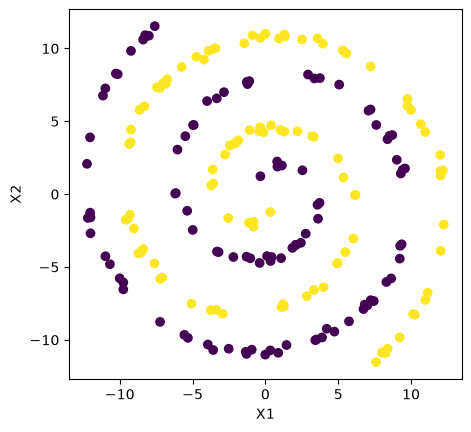

In [25]:
df = pd.read_csv(r'Ex13/U╠êbung 13/Data_2/data.csv')
X = df[['X1', 'X2']].values
y = df['y'].values

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.scatter(X[:,0], X[:,1], c=y)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_aspect(1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Daten skalieren
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, lr_pred)
print("Logistische Regression Accuracy:", accuracy_lr)

mlp = MLPClassifier(hidden_layer_sizes=(32, 32, 32, 32, 16), max_iter=50000, random_state=42)
mlp.fit(X_train_scaled, y_train)
mlp_pred = mlp.predict(X_test_scaled)
accuracy_mlp = accuracy_score(y_test, mlp_pred)
print("MLP Classifier Accuracy:", accuracy_mlp)

Logistische Regression Accuracy: 0.55
MLP Classifier Accuracy: 0.925


/home/ukas_engis/lukas/schule/DA/test/aufgaben/.myvenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Text(0, 0.5, 'X2')

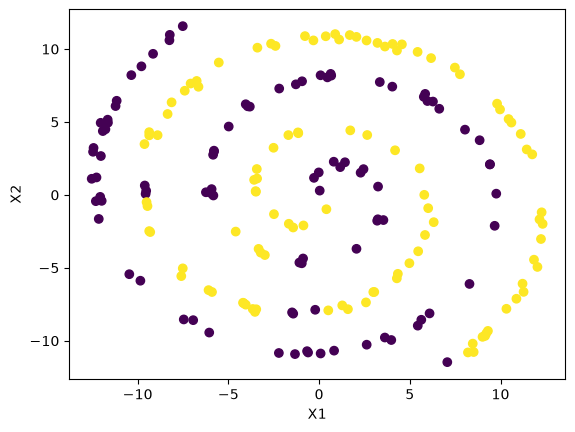

In [38]:
X_test = pd.read_csv(r"Ex13/U╠êbung 13/Data_2/X_test.csv")
s_X_test = scaler.transform(X_test)

y_test = mlp.predict(s_X_test)


fig = plt.figure()
plt.scatter(X_test['X1'], X_test['X2'], c=y_test)

plt.xlabel('X1')
plt.ylabel('X2')

Fehler in den Lösungen man mus die anderen Daten vom zweiten Datensatz auch noch in den scaler tun

/home/ukas_engis/lukas/schule/DA/test/aufgaben/.myvenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


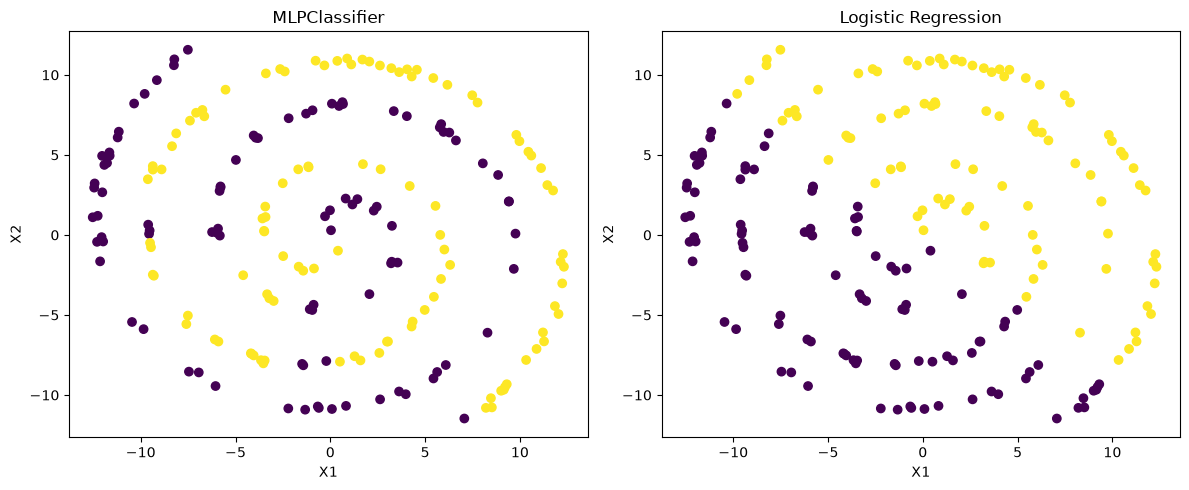

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

X_test = pd.read_csv(r"Ex13/U╠êbung 13/Data_2/X_test.csv")

s_X_test = scaler.transform(X_test)

y_test = mlp.predict(s_X_test)
y_2 = lr.predict(s_X_test)

# Zwei Plots nebeneinander
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# MLP
ax[0].scatter(X_test['X1'], X_test['X2'], c=y_test)
ax[0].set_title("MLPClassifier")
ax[0].set_xlabel("X1")
ax[0].set_ylabel("X2")

# Logistic Regression
ax[1].scatter(X_test['X1'], X_test['X2'], c=y_2)
ax[1].set_title("Logistic Regression")
ax[1].set_xlabel("X1")
ax[1].set_ylabel("X2")

plt.tight_layout()
plt.show()

# Aufgabe 3: Propagation durch ein neuronales Netz


Die beiden nächsten Funktionen sind dazu da um von einem Layer zum nächsten zu kommen oder zumm allerletzten. die dritte Funktion nimmt beide zusammen und macht den kompletten Prozess

In [39]:
def forward_propagation(weight_matrix, bias_vector, input_vector):
    """
    Performs forward propagation for one layer with ReLU activation function.
    
    Args:
        weight_matrix (numpy.ndarray): Weight matrix of shape (n_neurons, n_inputs).
        bias_vector (numpy.ndarray): Bias vector of shape (n_neurons,).
        input_vector (numpy.ndarray): Input vector of shape (n_inputs,).
    
    Returns:
        numpy.ndarray: Output vector of shape (n_neurons,).
    """
    # Matrix multiplikation des Inputs mit den Gewichten.
    z = np.dot(weight_matrix, input_vector)
    
    # Hinzuaddieren des Biasvektors
    z += bias_vector
    
    # Anwendend der ReLu Aktivierungsfunktion
    output = np.maximum(0, z)
    
    return output

def forward_sigmoid(weight_matrix, bias_vector, input_vector):
    """
    Performs forward propagation for one layer with sigmoid activation function.
    
    Args:
        weight_matrix (numpy.ndarray): Weight matrix of shape (n_neurons, n_inputs).
        bias_vector (numpy.ndarray): Bias vector of shape (n_neurons,).
        input_vector (numpy.ndarray): Input vector of shape (n_inputs,).
    
    Returns:
        numpy.ndarray: Output vector of shape (n_neurons,).
    """
    # Matrix multiplikation des Inputs mit den Gewichten.
    z = np.dot(weight_matrix, input_vector)
    
    # Hinzuaddieren des Biasvektors
    z += bias_vector
    
    # Anwendend der sigmoid Aktivierungsfunktion
    output = 1 / (1 + np.exp(-z))
    
    return output

In [40]:
testarray = np.arange(1, 5)

weight = np.ones((3, 4))
bias = np.array([0, -10, -12])

result_ReLU = np.array([10, 0, 0])
result_sigmoid = np.array([0.9999546, 0.5, 0.11920292])

In [41]:
print(forward_propagation(weight, bias, testarray))
print(forward_sigmoid(weight, bias, testarray))

[10.  0.  0.]
[0.9999546  0.5        0.11920292]


In [42]:
def forward_propagation_network(weights, biases, input_vector):
    """
    Performs forward propagation for a neural network with ReLU activation function.
    
    Args:
        weights (list): List of weight matrices for each layer.
        biases (list): List of bias vectors for each layer.
        input_vector (numpy.ndarray): Input vector of shape (n_inputs,).
    
    Returns:
        numpy.ndarray: Output vector of shape (n_outputs,).
    """
    output = input_vector
    
    # Iteration durch alle Layers
    n = len(weights)
    for i in range(n):
    # Beim letzten Layer wird die sigmoid Aktivierungsfunktion angewendet
        if i < n - 1:
            output = forward_propagation(weights[i], biases[i], output)
        else:
            output = forward_sigmoid(weights[i], biases[i], output)
            
    # Am Schluss runden wir noch, damit das Resultat immer 0 oder 1 ist (Klassifizierungsproblem)
    return np.round(output)

Text(0, 0.5, 'X2')

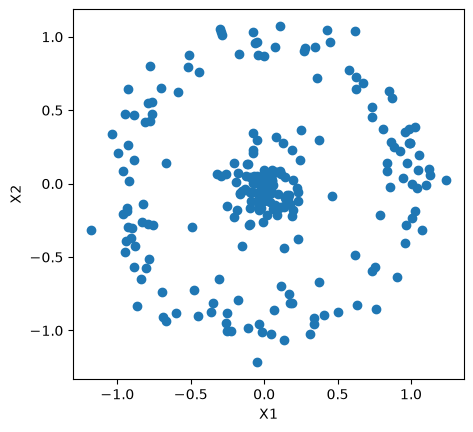

In [43]:
df = pd.read_csv(r'Ex13/U╠êbung 13/Data_3/data.csv')
X = df[['X1', 'X2']].values

fig  = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.scatter(X[:, 0], X[:,1])
ax.set_aspect(1) #die Seitenverhältnisse

ax.set_xlabel('X1')
ax.set_ylabel('X2')

In [ ]:

import pickle
weights = pickle.load(open('Ex13/U╠êbung 13/Data_3/weights.p', 'rb'))
biases = pickle.load(open('Ex13/U╠êbung 13/Data_3/biases.p', 'rb'))

### Pickle

`pickle` dient dazu, Python-Objekte (z. B. Modelle, Listen oder NumPy-Arrays) zu speichern und später wieder zu laden.

- `pickle.dump()` → Objekt speichern
- `pickle.load()` → Objekt laden

Dateimodi:
- `"rb"` = Read Binary (Binärdatei lesen)
- `"wb"` = Write Binary (Binärdatei schreiben)

In [ ]:
import pickle

# Modell speichern
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)


with open("Ex13/U╠êbung 13/Data_3/weights.p", "rb") as f:
    weights = pickle.load(f)

with open("Ex13/U╠êbung 13/Data_3/biases.p", "rb") as f:
    biases = pickle.load(f)

Text(0, 0.5, 'X2')

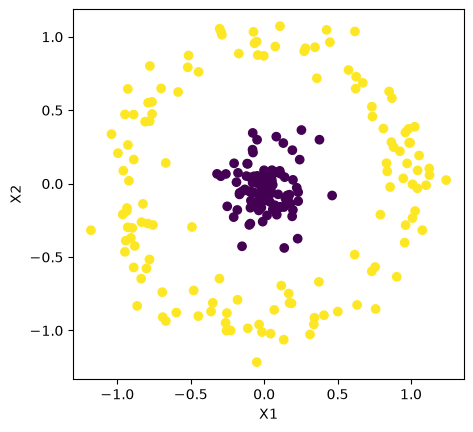

In [49]:
predictions = np.zeros(len(X[:, 0]))

for i in range(len(X[:, 0])):
    output = forward_propagation_network(
        weights,
        biases,
        [X[i, 0], X[i, 1]]
    )

    predictions[i] = output.item()

    
    # redictions[i] = forward_propagation_network(weights, biases, [X[i, 0], X[i, 1]])


fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ax.scatter(X[:, 0], X[:, 1], c=predictions)
ax.set_aspect(1)

ax.set_xlabel("X1")
ax.set_ylabel("X2")

Ex14

Es ist eine Aufgabe die es sich lohnt vielleicht nochmals anzuschauen

In [ ]:
df = pd.read_csv('Ex14/Ex 14/Data1/titanic.csv')
display(df.head())
df.info()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


So kann man mit fehlenden daten umgehen

ehandeln Sie die fehlenden Werte dann wie folgt:

1. Die Spalte `Cabin` fehlt bei über 70% der Passagiere — entfernen Sie sie komplett. Hinweis: Nutzen Sie `df.drop` 
2. Ersetzen Sie fehlende Werte in der Spalte `Age` durch den Mittelwert dieser Spalte.
3. Ersetzen Sie fehlende Werte in der Spalte `Embarked` durch den häufigsten Wert.



In [69]:
from sklearn.impute import SimpleImputer

print("Fehlende Werte vor der Bereinigung:")
print(df.isnull().sum()) #anzeigen wie wie das fehlt

# 1. Spalte Cabin entfernen (>70% fehlend)
df = df.drop(columns=['Cabin'])

# 2. Fehlende Altersangaben mit dem Mittelwert ersetzen
age_imputer = SimpleImputer(strategy='mean')
df[['Age']] = age_imputer.fit_transform(df[['Age']])

# 3. Fehlende Embarked-Werte mit dem häufigsten Wert ersetzen
embarked_imputer = SimpleImputer(strategy='most_frequent')
df[['Embarked']] = embarked_imputer.fit_transform(df[['Embarked']])

print("\nFehlende Werte nach der Bereinigung:")
print(df.isnull().sum())


Fehlende Werte vor der Bereinigung:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Fehlende Werte nach der Bereinigung:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [71]:

df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])
print(df.head())

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


Kategorische sachen die keine werte sondern male, female sind kann mna so bearbeiten

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded_cols = ohe.fit_transform(df[['Sex', 'Embarked']])

# Wir erstellen wieder ein DataFrame aus den kodierten Spalten, damit wir die Spaltennamen behalten
encoded_df = pd.DataFrame(encoded_cols, columns=ohe.get_feature_names_out(), index=df.index)

# Ursprüngliche Spalten entfernen und kodierte hinzufügen
df = df.drop(columns=['Sex', 'Embarked'])
df = pd.concat([df, encoded_df], axis=1) #zusammenlegen axis=1 heist die Spalten zusammenfügen (axis=0 sind die Zeilen)
print(df.head())

   Survived  Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  \
0         0       3  22.0      1      0   7.2500       1.0         0.0   
1         1       1  38.0      1      0  71.2833       0.0         0.0   
2         1       3  26.0      0      0   7.9250       0.0         0.0   
3         1       1  35.0      1      0  53.1000       0.0         0.0   
4         0       3  35.0      0      0   8.0500       1.0         0.0   

   Embarked_S  
0         1.0  
1         0.0  
2         1.0  
3         1.0  
4         1.0  


taregt_enc ersetzt den Wert also erstes Argumnent Pclass mit dem durchschnitt des zweiten arguments

Der `TargetEncoder` ersetzt jede Kategorie eines Merkmals durch den durchschnittlichen Wert der Zielvariable aller Datenpunkte, die zu dieser Kategorie gehören. Im Beispiel wird jede `Pclass` durch die durchschnittliche Überlebensrate (`Survived`) aller Passagiere derselben Klasse ersetzt.

In [ ]:
from sklearn.preprocessing import TargetEncoder

target_enc = TargetEncoder()
df['Pclass'] = target_enc.fit_transform(df[['Pclass']], df['Survived'])
print(df['Pclass'].unique())

[0.24139722 0.64106548 0.23106399 0.6136137  0.25089852 0.46467972
 0.24517532 0.49257076 0.46696763 0.24455075 0.61851282 0.45660115
 0.63326967 0.47904763 0.63442325]


In [74]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,0.241397,22.0,1,0,7.2500,1.0,0.0,1.0
1,1,0.641065,38.0,1,0,71.2833,0.0,0.0,0.0
2,1,0.231064,26.0,0,0,7.9250,0.0,0.0,1.0
3,1,0.613614,35.0,1,0,53.1000,0.0,0.0,1.0
4,0,0.250899,35.0,0,0,8.0500,1.0,0.0,1.0


KNNs und decision Trees

In [4]:
df = pd.read_csv('Ex14/Ex 14/Data2/titanic_cleaned.csv')

X = df.drop(columns=['Survived'])
y = df['Survived']


Zuerst daten scaler machen

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

cross_val_results = cross_val_score(KNeighborsClassifier(n_neighbors=20), X_scaled, y, cv=5, scoring='accuracy')
print("Durchschnittliche Genauigkeit:", np.mean(cross_val_results))

Durchschnittliche Genauigkeit: 0.812560416797439


Man kann den decision Tree darstellen der muss mna nicht skalieren da er auf Entscheidungen und nicht auf abstand basiert

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4, 5, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_leaf': [1, 2, 4],
}

grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, scoring='accuracy', cv=5)
grid_search_dt.fit(X, y)

print("Beste Parameter:", grid_search_dt.best_params_)
print(f"Beste CV-Genauigkeit (DT):  {grid_search_dt.best_score_:.3f}")

Beste Parameter: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1}
Beste CV-Genauigkeit (DT):  0.816


und man kann es auch visualiesieren

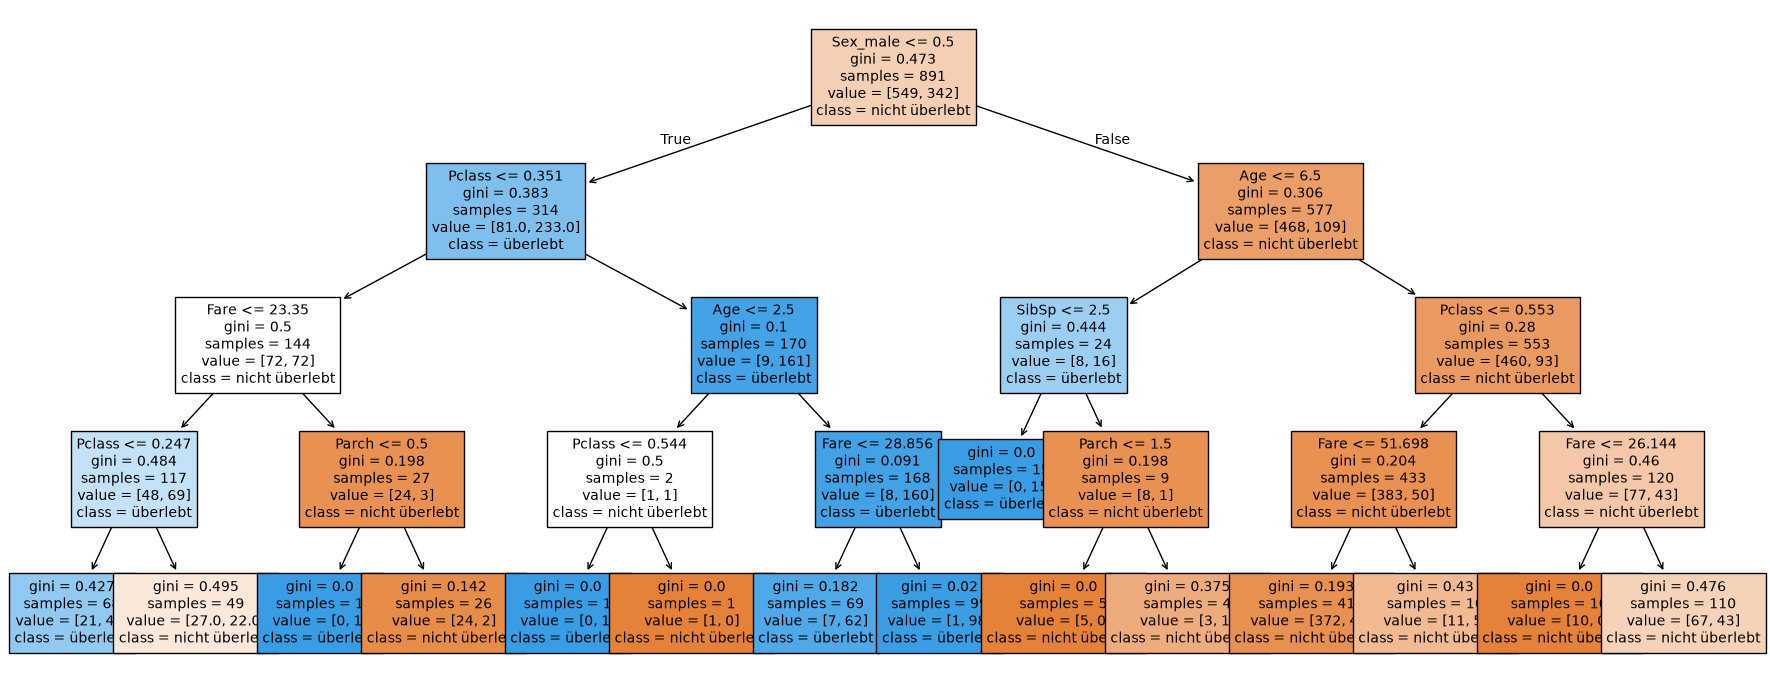

In [ ]:
from sklearn.tree import plot_tree

best_dt = grid_search_dt.best_estimator_

class_names = ['nicht überlebt' if c == 0 else 'überlebt' for c in best_dt.classes_]
plt.figure(figsize=(18, 7))
plot_tree(best_dt, max_depth=4, feature_names=X.columns, class_names=class_names, filled=True, fontsize=10)
plt.tight_layout()
plt.show()

Ein Decision Tree wird von oben nach unten gelesen: Jeder Knoten enthält eine Entscheidungsregel (z. B. `Age <= 9.5`), bei der man bei **Ja** nach links und bei **Nein** nach rechts folgt. Zusätzlich zeigt jeder Knoten den **Gini-Wert** (Reinheit der Klassen, je kleiner desto besser getrennt), die Anzahl der Datenpunkte (**samples**), die Klassenverteilung (**value**, Anzahl der Beispiele je Klasse) sowie die vorhergesagte Mehrheitsklasse (**class**). Die Vorhersage erfolgt im Blattknoten, wobei die dort angegebene Mehrheitsklasse das Klassifikationsergebnis darstellt.

K-means Clustering 2D

In [7]:
def euclidian_distance(p1, p2):
    '''Calculate the Euclidian distance between two points p1 and p2.'''
    return np.sqrt(np.sum((p1 - p2)**2))

Man brauch eine zuweisung welchen den Punkten einen Schwerpunkt zuordnet

In [8]:
n_clusters = 2
points = pickle.load(open('Ex14/Ex 14/Data3/testpoints.p', 'rb'))
centroids = pickle.load(open('Ex14/Ex 14/Data3/testcentroids.p', 'rb'))

Für jeden Punkt die Distanz zu jedem centroid berechnen und dan das assigment zu nächsten machen

In [9]:
# Initialisiere Array für die Zuweisungen
assignment = np.zeros(len(points), dtype=int)
for i, p in enumerate(points):
    # Berchne die Distanz zu jedem Schwerpunkt und speichere den Index des nächsten
    min_distance = np.inf
    for j, c in enumerate(centroids):
        distance = euclidian_distance(p, c)
        if distance < min_distance:  # Kleinere Distanz gefunden?
            min_distance = distance
            assignment[i] = j

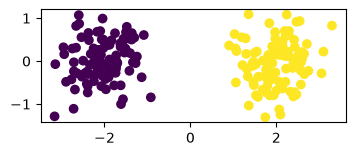

In [21]:
# Überprüfen
cm = 1 / 2.54
fig = plt.figure(figsize=(10*cm, 10*cm))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(points[:, 0], points[:, 1], c=assignment)
ax.set_aspect(1)

In [10]:
n_clusters = 2
points = pickle.load(open('Ex14/Ex 14/Data3/testpoints.p', 'rb'))
assignment = pickle.load(open('Ex14/Ex 14/Data3/testassignment.p', 'rb'))

Die Schwerpunkte der Cluster berechnen

In [11]:
# Array zum Speichern der Anzahl Punkte in jedem Cluster
cluster_size = np.zeros(n_clusters)

# Array zum Speichern der summierten Koordinaten
coord_sum = np.zeros(shape=(n_clusters, 2))

for i, p in enumerate(points):
    # Zum Punkt zugehörigen Cluster auswählen
    cluster_ind = assignment[i]

    # Koordinaten des Punktes zur Summe addieren, Grösse des Clusters um eins erhöhen.
    coord_sum[cluster_ind] += p
    cluster_size[cluster_ind] += 1

# Jede der Koordinatensummen wird durch die entsprechende Clustergrösse dividiert -> Mittelwert
new_centroids = np.zeros(shape=(n_clusters, 2))
for j in range(len(new_centroids)):
    new_centroids[j] = coord_sum[j] / (cluster_size[j] + 1e-9)

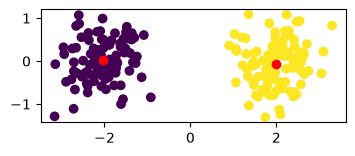

In [24]:
# Überprüfen
cm = 1 / 2.54
fig = plt.figure(figsize=(10*cm, 10*cm))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(points[:, 0], points[:, 1], c=assignment)
ax.scatter(new_centroids[:, 0], new_centroids[:, 1], c='r')
ax.set_aspect(1)

## Jetzt will man ein funktion machen die die centroids und die assignment berechnet. 

Setzen Sie nun die zwei Schritte zum iterativen Algorithmus zusammen. Schreiben Sie hierzu eine Funktion, die folgende Argumente nimmt:

- `points`: Das Array mit den Datenpunkten.
- `n_clusters`: Ein Integer mit der Anzahl Clusters, in die die Punkte eingeteilt werden sollen.
- `tol`: Eine absolute Toleranz für die Abbruchbedingung (siehe unten).
- `max_iterations`: Ein Integer, das angibt, nach wie vielen Durchgängen die Iteration spätestens abgebrochen wird.

Für die Initialisierung erstellen sie ein Zufallsgenerator-Objekt mit `rng = np.random.default_rng()` und verwenden dessen Funktion `rng.choice()` um zufällige Punkte aus dem Datensatz zu wählen.

Die zwei Schritten kommen dann in eine `while`-Schleife mit folgenden Abbruchbedingungen:

- Kein Schwerpunkt hat sich im letzten Durchlauf um mehr als `tol` verschoben, **oder**
- Die Anzahl Durchläufe ist grösser als `max_iterations`.

Am Ende gibt die Funktion die Arrays `assignment` und `centroids` aus, die die Zuweisung der Punkte zu Clusters und die Schwerpunkte der Clusters enthalten.

In [42]:
def euclidian_distance(p1, p2):
    '''Calculate the Euclidian distance between two points p1 and p2.'''
    return np.sqrt(np.sum((p1 - p2)**2))


def k_means(points, n_clusters=3, tol=1e-3, max_iterations=100, centroids=None):
    '''Assign points in M-D space to n_clusters different clusters.
    Args:
        points (Array): 2D-Array with shape (N, M) containing N datapoints points in M-D space.
        n_clusters (int): Number of clusters
        tol (float): tolerance for centroid update to stop the iteration.
                     Iteration stops when the sum of distances between new
                     and old centroid locations is smaller than tol.
        max_iterations (int): Maximum iterations stop condition
        
    Returns:
        assignment: 1D-Array of length N with the assignment for each point to a cluster.
                    Assignment corresponds to index in centroids array.
        centroids: 2D-Array with shape (n_clusters, M) giving the final centroid locations.'''
    
    # Find dimensionality of points
    dim = points.shape[1]
    
    # Inital centroids are chosen randomly from dataset.
    # np.random.seed(1)  # optional fixed seed for reproducible RNG

    # Initial centroids
    if centroids is None:
        rng = np.random.default_rng()
        centroids = rng.choice(points, n_clusters, replace=False)
        print("Es wurden keine Centroids gegeben. Sie werden zufällig ausgewählt.")
    else:
        centroids = np.array(centroids)

        if len(centroids) > n_clusters:
            print("Es wurden mehr Zentren als benötigt übergeben. Es werden nur die ersten verwendet.")
            centroids = centroids[:n_clusters]

        elif len(centroids) < n_clusters:
            print("Es wurden zu wenige Zentren übergeben. Fehlende Zentren werden zufällig ergänzt.")
            rng = np.random.default_rng()

            # Zufällige zusätzliche Zentren auswählen
            additional = rng.choice(points, n_clusters - len(centroids), replace=False)

            # Anhängen
            centroids = np.vstack((centroids, additional))
        else:
            print("Die Anzahl gegebener Centroids und Cluster stimmen überein.")
        
    
    # Initialize a list that stores the assigment of points to centroids
    assignment = np.zeros(len(points), dtype=int)
    
    # Iterate over assignment and centroid recalculation until centroids are not moving anymore
    centroid_shift = np.inf
    num_iter = 0
    while np.max(centroid_shift) > tol and num_iter < max_iterations:
        ## Assignment
        for i, p in enumerate(points):
            # calculate Euclidian distance to each centroid, save the index of the
            # centroid with smallest distance
            min_distance = np.inf
            for j, c in enumerate(centroids):
                distance = euclidian_distance(p, c)
                if distance < min_distance:
                    min_distance = distance
                    assignment[i] = j
        
        ## Recalculate centroids as means of each cluster
        # Array that stores number of points in each cluster
        cluster_size = np.zeros(n_clusters)
        
        # Array that stores sum of the coordinates of the points in each cluster
        # Used to calculate the mean of the coordinates -> new centroids
        coord_sum = np.zeros(shape=(n_clusters, dim))
        
        for i, p in enumerate(points):
            # Select assigned cluster
            cluster_ind = assignment[i]
            
            # Add x and y coordinates centroid coordinates, increase number of points in cluster by 1
            coord_sum[cluster_ind] += p
            cluster_size[cluster_ind] += 1
        
        # Divide each of the coord_sum by the corresponding cluster_size
        # -> we have calculated the mean of the x and y coordinates of all points in each cluster
        new_centroids = np.zeros(shape=(n_clusters, dim))
        for j in range(len(new_centroids)):
            new_centroids[j] = coord_sum[j] / (cluster_size[j] + 1e-9)
        
        # calculate the total shift
        centroid_shift = np.zeros(n_clusters)
        for j in range(len(new_centroids)):
            centroid_shift[j] = euclidian_distance(centroids[j], new_centroids[j])  # Norm of the vector
            
        # Update centroids and number of iterations
        centroids = np.copy(new_centroids)
        num_iter += 1
    
    # End while
    
    if num_iter >= max_iterations - 1:
        print('Warning: maximum iterations reached. Result might not be converged.')
    
    # Return assigments
    return assignment, centroids

Zu Beginn werden zufällig drei Datenpunkte als Clusterzentren ausgewählt. Anschließend werden alle Datenpunkte dem jeweils nächstgelegenen Zentrum zugeordnet und danach die Clusterzentren als Mittelwert aller Punkte eines Clusters neu berechnet. Dieser Vorgang wird wiederholt, bis sich die Clusterzentren nicht mehr wesentlich verändern.

Hier ist eine Datenmenge man kann erkennen das 3 centroids sinvoll wäre

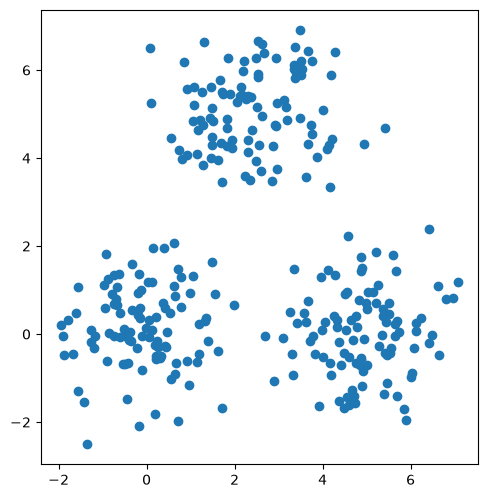

In [24]:
# Daten Laden und Plotten
points = np.loadtxt('Ex14/Ex 14/Data3/xy_dataset.txt')

cm = 1 / 2.54
fig = plt.figure(figsize=(15*cm, 15*cm))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(points[:, 0], points[:, 1])
ax.set_aspect(1)

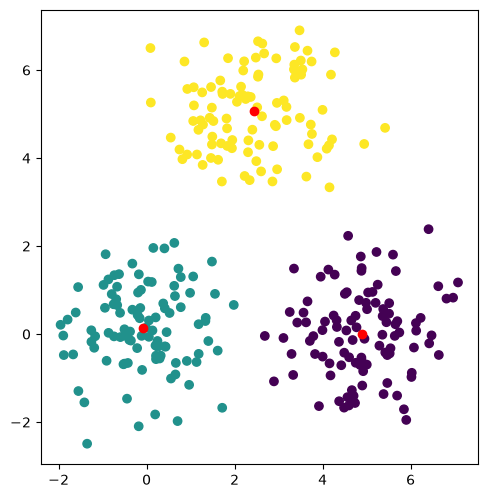

In [25]:
# k-means Clustering anwenden, Resultat plotten
assignment, centroids = k_means(points, n_clusters=3, max_iterations=10)

cm = 1 / 2.54
fig = plt.figure(figsize=(15*cm, 15*cm))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(points[:, 0], points[:, 1], c=assignment)
ax.scatter(centroids[:, 0], centroids[:, 1], c='r')
ax.set_aspect(1)

Mit make Bloobls kann man eigene Datensäten generieren. und dann mit dem vorherigen code verallgemeinern.

Die Anzahl gegebener Centroids und Cluster stimmen überein.


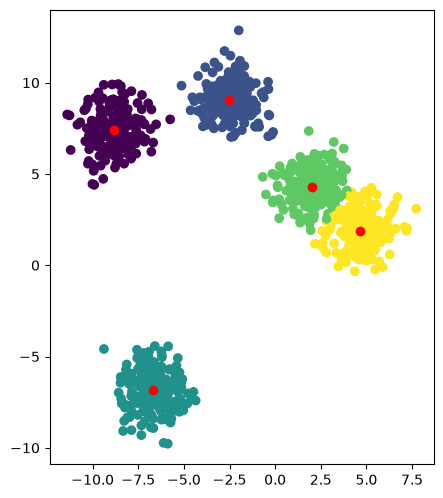

In [53]:

# Eigene Datensätze generieren und Resultat plotten
n_clusters = 5
points, _ = make_blobs(centers=n_clusters, n_samples=1000, random_state = 42)

centroids =[[-9,7],[-2.5,10],[-6,-6],[2.5,5],[5,0]]

# centroids = None

assignment, centroids = k_means(points, n_clusters=n_clusters, max_iterations=20,centroids=centroids)

cm = 1 / 2.54
fig = plt.figure(figsize=(15*cm, 15*cm))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(points[:, 0], points[:, 1], c=assignment)
ax.scatter(centroids[:, 0], centroids[:, 1], c='r')
ax.set_aspect(1)

Wenn Sie einige zufällige Datensätze ausprobieren, werden Sie sehen, dass der Algorithmus die Cluster nicht immer korrekt identifizieren kann. Das liegt an der zufälligen Initialisierung und daran, dass der Algorithmus relativ simpel ist und sozusagen in lokalen Minima stecken bleiben kann. Allerdings ist die Konvergenz erstaunlich schnell, meistens braucht es nur 4 oder 5 Iterationen, um zum Resultat zu gelangen.

jetzt alles nur noch in den ordner Daten legen und man ist vorübergehend fertg